# 国別CO₂排出量：総量・一人当たり・長期変化

run_id: `v020-exp-41`。取得・分析はJupyter MCPで実行。排出の人口規模・経済規模による見え方を記述的に比較する。

In [1]:
from pathlib import Path
import os, sys, json, hashlib, inspect, contextlib, io, zipfile
from datetime import datetime, timezone
from dataclasses import asdict
repo = Path('/home/nahisaho/GitHub/jupytermind')
sys.path.insert(0, str(repo / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(repo / 'benchmark/projects')
import nbformat
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Image
from ai_data_scientist import project_manager, language_router, lifecycle
RUN_ID = 'v020-exp-41'
handle = project_manager.resolve_project('kaggle-v020-kaggle-exp-41-co2-emissions')
project_manager.ensure_notebook(handle)
data_dir = project_manager.ensure_data_dir(handle)
lifecycle.register_run(RUN_ID, handle.notebook_path)
phase_log = []
def log_phase(phase, event):
    phase_log.append({'time': datetime.now(timezone.utc).isoformat(), 'phase': phase, 'event': event})
@contextlib.contextmanager
def execution_phase(name):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('キャンセルが要求されています')
    lifecycle.mark_execution_start(RUN_ID)
    log_phase(name, 'execution_start')
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        log_phase(name, 'failed')
        raise
    finally:
        lifecycle.mark_execution_end(RUN_ID)
        log_phase(name, 'execution_end')
def queued_write(mutation):
    lifecycle.mark_write_start(RUN_ID)
    log_phase('notebook', 'write_start')
    try:
        return project_manager.enqueue_write(handle, mutation)
    finally:
        lifecycle.mark_write_end(RUN_ID)
        log_phase('notebook', 'write_end')
def add_cells(cells):
    queued_write(lambda nb: nb.cells.extend(cells))
print({'run_id': RUN_ID, 'language': language_router.detect_language('国別CO2排出データの分析'), 'notebook': str(handle.notebook_path)})


{'run_id': 'v020-exp-41', 'language': 'ja', 'notebook': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-41-co2-emissions/notebooks/kaggle-v020-kaggle-exp-41-co2-emissions.ipynb'}


In [2]:
with execution_phase('Kaggle公開データ検索'):
    kaggle_log = []
    kaggle_candidates = []
    api = None
    try:
        # 認証処理・SDKの標準出力は保存せず、例外本文も秘密保護のため表示しない。
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
        kaggle_log.append({'action': 'KaggleApi().authenticate()', 'status': 'ok'})
        for query in ['co2 emissions by country', 'our world in data co2']:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                found = api.dataset_list(search=query, page=1)
            for ds in found:
                kaggle_candidates.append({'search': query, 'slug': ds.ref, 'title': ds.title, 'bytes': getattr(ds, 'total_bytes', None)})
        kaggle_log.append({'action': 'dataset_list(search=...)', 'status': 'ok'})
    except Exception as exc:
        kaggle_log.append({'action': 'Kaggle検索・認証', 'status': 'failed', 'exception_type': type(exc).__name__, 'message': '詳細は認証情報保護のため非表示'})
    print(json.dumps(kaggle_log, ensure_ascii=False))
    display(pd.DataFrame(kaggle_candidates).drop_duplicates('slug') if kaggle_candidates else pd.DataFrame(columns=['slug','title']))


[{"action": "KaggleApi().authenticate()", "status": "ok"}, {"action": "dataset_list(search=...)", "status": "ok"}]


,search,slug,title,bytes
0,co2 emissions by country,thedevastator/global-fossil-co2-emissions-by-c...,Emissions by Country,1789031
1,co2 emissions by country,ulrikthygepedersen/co2-emissions-by-country,CO2 Emissions,116974
2,co2 emissions by country,lucalullo/global-co2-emissions-by-country-1950...,global-co2-emissions-by-country-1950-2024,655347
3,co2 emissions by country,yoannboyere/co2-ghg-emissionsdata,CO2_GHG_emissions-data,150835
4,co2 emissions by country,iamsouravbanerjee/production-based-co2-emissions,Countrywise Production-Based CO2 Emissions,5260
5,co2 emissions by country,saloni1712/co2-emissions,CO2 Emissions by Sectors,1287992
6,co2 emissions by country,shahriarkabir/co2-and-greenhouse-gas-emissions...,CO2 and Greenhouse Gas Emissions by Region,2878
7,co2 emissions by country,nelgiriyewithana/countries-of-the-world-2023,Global Country Information Dataset 2023,24063
8,co2 emissions by country,shreyaskeote23/countries-by-carbon-dioxide-emi...,CO2 Emissions by Country,8690
9,co2 emissions by country,sergionefedov/global-climate-and-energy-transi...,Global Climate & Energy Transition 2000-2026,144784


## Kaggleファイル選定

検索で実在を確認したOWID由来候補から、年・国・人口・GDP・CO₂を含むCSVを優先する。データセットを推測で置き換えない。

In [3]:
with execution_phase('Kaggleファイル一覧'):
    file_candidates = []
    for slug in ['rajdahiwal/global-co2ghg-emissions-our-world-in-data', 'danielrpdias/co2-and-greenhouse-gas-emissions', 'mexwell/global-co2-and-greenhouse-gas-emissions']:
        if slug not in {x['slug'] for x in kaggle_candidates}:
            continue
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                response = api.dataset_list_files(slug)
            for f in response.files:
                file_candidates.append({'slug': slug, 'file': f.name, 'bytes': getattr(f, 'total_bytes', None)})
            kaggle_log.append({'action': 'dataset_list_files', 'slug': slug, 'status': 'ok'})
        except Exception as exc:
            kaggle_log.append({'action': 'dataset_list_files', 'slug': slug, 'status': 'failed', 'exception_type': type(exc).__name__})
    display(pd.DataFrame(file_candidates))
    print(json.dumps(kaggle_log, ensure_ascii=False))


[{"action": "KaggleApi().authenticate()", "status": "ok"}, {"action": "dataset_list(search=...)", "status": "ok"}, {"action": "dataset_list_files", "slug": "rajdahiwal/global-co2ghg-emissions-our-world-in-data", "status": "ok"}, {"action": "dataset_list_files", "slug": "danielrpdias/co2-and-greenhouse-gas-emissions", "status": "ok"}, {"action": "dataset_list_files", "slug": "mexwell/global-co2-and-greenhouse-gas-emissions", "status": "ok"}]


,slug,file,bytes
0,rajdahiwal/global-co2ghg-emissions-our-world-i...,OWID_CB.csv,1550551428
1,danielrpdias/co2-and-greenhouse-gas-emissions,owid-co2-data.csv,5173111
2,mexwell/global-co2-and-greenhouse-gas-emissions,owid-co2-codebook.csv,24123
3,mexwell/global-co2-and-greenhouse-gas-emissions,owid-co2-data.csv,13153941


## 取得履歴・ファイル同一性

`mexwell/global-co2-and-greenhouse-gas-emissions`は本体CSVとデータ辞書が同梱され、必要変数の定義を検証できるため選定する。大容量OWID_CB候補は採用しない。再実行時はSHA-256一致済みローカルファイルを使用し、初回取得日時を維持する。

In [4]:
with execution_phase('Kaggle CSV取得'):
    selected_slug = 'mexwell/global-co2-and-greenhouse-gas-emissions'
    filenames = ['owid-co2-data.csv', 'owid-co2-codebook.csv']
    provenance_path = data_dir / 'provenance.json'
    provenance = json.loads(provenance_path.read_text()) if provenance_path.exists() else {}
    acquisition_ok = True
    for filename in filenames:
        dest = data_dir / filename
        record = provenance.get(filename)
        cache_valid = dest.exists() and record and hashlib.sha256(dest.read_bytes()).hexdigest() == record['sha256']
        if not cache_valid:
            try:
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    api.dataset_download_file(selected_slug, filename, path=str(data_dir), force=True, quiet=True)
                if not dest.exists():
                    zipped = data_dir / (filename + '.zip')
                    with zipfile.ZipFile(zipped) as archive:
                        names = archive.namelist()
                        member = next(n for n in names if Path(n).name == filename)
                        dest.write_bytes(archive.read(member))
                provenance[filename] = {'owner_dataset_slug': selected_slug, 'file': filename, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(dest.read_bytes()).hexdigest(), 'bytes': dest.stat().st_size, 'method': 'KaggleApi.dataset_download_file'}
                provenance_path.write_text(json.dumps(provenance, ensure_ascii=False, indent=2), encoding='utf-8')
                kaggle_log.append({'action':'dataset_download_file','file':filename,'status':'ok'})
            except Exception as exc:
                acquisition_ok = False
                kaggle_log.append({'action':'dataset_download_file','file':filename,'status':'failed','exception_type':type(exc).__name__})
                white_paper = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
                print('取得失敗。指定white-paperの同一データセット公開CSVのみフォールバック可。')
                if white_paper.exists():
                    text = white_paper.read_text(encoding='utf-8')
                    pos = text.find(selected_slug)
                    print(text[max(0,pos-300):pos+2500] if pos >= 0 else '同じslugの明記なし。別データは選ばない。')
                else:
                    print('white-paper.mdなし。フォールバックは実施しない。')
        else:
            kaggle_log.append({'action':'local_cache','file':filename,'status':'sha256_verified'})
    display(pd.DataFrame(provenance.values()))
    print(json.dumps(kaggle_log[-2:], ensure_ascii=False))
    if not acquisition_ok:
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('対応データの取得失敗。分析停止。')
    raw = pd.read_csv(data_dir / filenames[0])
    codebook = pd.read_csv(data_dir / filenames[1])
    print('shape:', raw.shape, 'year:', raw.year.min(), raw.year.max())
    print('columns:', list(raw.columns))
    display(codebook.head(3))
    display(codebook[codebook.iloc[:,0].isin(['co2','co2_per_capita','co2_per_gdp','gdp','population','iso_code','consumption_co2','consumption_co2_per_capita'])])


[{"action": "local_cache", "file": "owid-co2-data.csv", "status": "sha256_verified"}, {"action": "local_cache", "file": "owid-co2-codebook.csv", "status": "sha256_verified"}]
shape: (48058, 79) year: 1750 2022
columns: ['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 

,owner_dataset_slug,file,retrieved_at_utc,sha256,bytes,method
0,mexwell/global-co2-and-greenhouse-gas-emissions,owid-co2-data.csv,2026-10-01T22:35:54.966328+00:00,2332de36c27f0676999b35dac119df5a1a71ddb76130e1...,13153941,KaggleApi.dataset_download_file
1,mexwell/global-co2-and-greenhouse-gas-emissions,owid-co2-codebook.csv,2026-10-01T22:35:55.149248+00:00,078a3c02f974d4ba1faea35da0f814331999e867db5e97...,24123,KaggleApi.dataset_download_file


,column,description,unit,source
0,country,Country - Geographic location.,NaN,Our World in Data - Regions (2022)
1,year,Year - Year of observation.,NaN,Our World in Data - Regions (2022)
2,iso_code,ISO code - ISO 3166-1 alpha-3 three-letter cou...,NaN,International Organization for Standardization...


,column,description,unit,source
2,iso_code,ISO code - ISO 3166-1 alpha-3 three-letter cou...,NaN,International Organization for Standardization...
3,population,"Population - Population by country, available ...",persons,Population based on various sources (2023) [ht...
4,gdp,GDP - Gross domestic product measured in inter...,international-$ in 2011 prices,Maddison Project Database 2020 (Bolt and van Z...
7,co2,Annual CO₂ emissions - Annual total emissions ...,million tonnes,Global Carbon Budget (2023) [https://globalcar...
16,co2_per_capita,Annual CO₂ emissions (per capita) - Annual tot...,tonnes per person,Global Carbon Budget (2023) [https://globalcar...
17,co2_per_gdp,Annual CO₂ emissions per GDP (kg per internati...,kilograms per international-$,Global Carbon Budget (2023) [https://globalcar...
21,consumption_co2,Annual consumption-based CO₂ emissions - Annua...,million tonnes,Global Carbon Budget (2023) [https://globalcar...
22,consumption_co2_per_capita,Per capita consumption-based CO₂ emissions - A...,tonnes per person,Global Carbon Budget (2023) [https://globalcar...


## データ定義manifest・欠測・意味的検査

単位と排出境界は同梱codebookの記述を根拠にする。地域集計・World・所得階層（OWID_コード、ISO欠測）を国別比較から除外する。国と属領は厳密な主権国家リストではない。欠測は0で補わず、比較ごとに有効行数を報告する。

In [5]:
with execution_phase('定義・品質・対象年'):
    from ai_data_scientist import ingestion, cleaning, eda, data_definition, data_quality, analysis_assumptions, sensitivity, stats_analysis, visualization, notebook_audit, insight_engine
    from ai_data_scientist.data_definition import FieldValue
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(data_dir / 'owid-co2-data.csv')), row_limit=100000)
    assert not loaded.truncated, '読み込みが切り詰められています'
    clean_report = cleaning.clean_dataset(loaded.dataframe, operation='drop_duplicates')
    df = clean_report.dataframe.copy()
    print('cleaning:', {'rows_before':clean_report.rows_before, 'rows_after':clean_report.rows_after, 'rows_removed':clean_report.rows_removed, 'columns_affected':clean_report.columns_affected})
    fields = ['country','year','iso_code','co2','co2_per_capita','population','gdp','co2_per_gdp','consumption_co2','consumption_co2_per_capita','co2_including_luc']
    definitions = codebook.set_index('column')
    selected_definitions = codebook[codebook.column.isin(fields)].fillna('記載なし').to_dict('records')
    print('データ辞書:', json.dumps(selected_definitions, ensure_ascii=False, indent=2))
    print('取得manifest:', json.dumps(provenance, ensure_ascii=False, indent=2))
    variable_manifest = {}
    for col in fields:
        row = definitions.loc[col]
        variable_manifest[col] = {'definition':FieldValue(row.description, 'verified', '同梱codebook'), 'unit':FieldValue(row.unit if pd.notna(row.unit) else '単位なし（識別子・暦年）', 'verified', '同梱codebook'), 'source':FieldValue(row.source, 'verified', '同梱codebook')}
    definition_manifest = data_definition.build_manifest(source={'kaggle':FieldValue(selected_slug,'verified','SDK検索'), 'files':FieldValue(provenance,'verified','SHA-256'), 'license':FieldValue(None,'unknown','ライセンス本文未取得')}, dataset_scope={'observed_years':FieldValue([int(df.year.min()),int(df.year.max())],'verified','実データ'), 'country_scope':FieldValue('ISO alpha-3国・属領、歴史的国を含み得る','inferred','iso_code抽出')}, variables=variable_manifest, transformations=('完全一致重複のみ除去','ISO alpha-3かつ非集計行','欠測補完なし'))
    unknown_fields = [(k,asdict(v)) for k,v in definition_manifest.unresolved_fields()]
    inferred_fields = [(f'dataset_scope.{k}',asdict(v)) for k,v in definition_manifest.dataset_scope.items() if isinstance(v,FieldValue) and v.status=='inferred']
    print('未確定定義:', json.dumps({'unknown':unknown_fields,'inferred':inferred_fields},ensure_ascii=False))
    (data_dir/'data_definition_manifest.json').write_text(json.dumps(asdict(definition_manifest),ensure_ascii=False,indent=2,default=str),encoding='utf-8')
    countries = df[df.iso_code.fillna('').str.fullmatch('[A-Z]{3}')].copy()
    countries['country_year_key'] = countries.iso_code + ':' + countries.year.astype(str)
    quality = data_quality.detect_anomalies(countries, schema={'country_year_key':{'not_null':True,'unique':True},'year':{'min':1750,'max':2022,'not_null':True},'population':{'min':1},'gdp':{'min':1},'co2':{'min':0},'co2_per_capita':{'min':0},'co2_per_gdp':{'min':0}})
    print('意味的異常:',json.dumps([{'column':q.column,'rule':q.rule,'row_count':q.row_count,'example_rows':list(q.row_indices[:8])} for q in quality],ensure_ascii=False))
    assert not countries.country_year_key.duplicated().any(), '国・年の重複あり'
    overview = eda.explore(countries[fields])
    print('EDA result fields:', list(vars(overview)))
    missing = countries[fields].isna().agg(['sum','mean']).T.rename(columns={'sum':'欠測数','mean':'欠測率'})
    display(missing)
    coverage = countries.groupby('year').agg(国属領数=('country','size'),CO2あり=('co2','count'),人口あり=('population','count'),一人当たりあり=('co2_per_capita','count'),GDPあり=('gdp','count'),GDP強度あり=('co2_per_gdp','count'))
    display(coverage.tail(15))
    latest_year = int(countries.loc[countries.co2.notna(),'year'].max())
    complete_gdp = countries.dropna(subset=['co2','population','gdp','co2_per_capita','co2_per_gdp'])
    gdp_coverage = complete_gdp.groupby('year').size()
    economy_year = int(gdp_coverage[gdp_coverage>=100].index.max())
    latest = countries[countries.year.eq(latest_year)].copy()
    economy = countries[countries.year.eq(economy_year)].copy()
    print(json.dumps({'latest_emissions_year':latest_year,'economic_comparison_year':economy_year,'latest_n':len(latest),'economic_n':len(economy),'excluded_aggregate_rows':len(df)-len(countries)},ensure_ascii=False))
    consistency = []
    for col, calculated in [('co2_per_capita', countries.co2*1e6/countries.population),('co2_per_gdp',countries.co2*1e9/countries.gdp)]:
        valid = countries[col].notna() & calculated.notna() & np.isfinite(calculated)
        delta = (countries.loc[valid,col]-calculated[valid]).abs()
        # 公開列は小数3桁丸め。co2本体の0.001Mt丸めも分母が小さいと大きく効く。
        denom = countries.loc[valid,'population' if col=='co2_per_capita' else 'gdp']
        tolerance = 0.00051 + (0.00051 * (1e6 if col=='co2_per_capita' else 1e9) / denom)
        consistency.append({'column':col,'n':int(valid.sum()),'max_abs_delta':float(delta.max()),'beyond_rounding':int((delta>tolerance).sum())})
    print('分母・単位・丸め整合性:',json.dumps(consistency,ensure_ascii=False))


cleaning: {'rows_before': 48058, 'rows_after': 48058, 'rows_removed': 0, 'columns_affected': ['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co

,欠測数,欠測率
country,0.0,0.000000
year,0.0,0.000000
iso_code,0.0,0.000000
co2,15852.0,0.399124
co2_per_capita,16918.0,0.425964
population,2971.0,0.074804
gdp,25169.0,0.633708
co2_per_gdp,26209.0,0.659894
consumption_co2,35897.0,0.903820
consumption_co2_per_capita,35897.0,0.903820


,国属領数,CO2あり,人口あり,一人当たりあり,GDPあり,GDP強度あり
year,,,,,,
2008,219,213,216,213,165,164
2009,219,213,216,213,165,164
2010,219,213,216,213,165,164
2011,219,213,216,213,165,164
2012,219,213,216,213,165,164
2013,219,213,216,213,165,164
2014,219,213,216,213,165,164
2015,219,213,216,213,165,164
2016,219,213,216,213,165,164


## 分析前提manifest・適用範囲

総量と一人当たりは2022年、GDP比較は全変数の観測がある最新年2018年に統一する。2019年以降のGDPを外挿しない。長期変化は1990年を基準に同じ国の端点を比較し、国境・領土変更の影響を残る限界とする。相関は因果効果ではなく、人口・GDPで割る指標には数学的な共有成分もある。

In [6]:
with execution_phase('分析前提'):
    assumptions_manifest = analysis_assumptions.AnalysisAssumptionManifest(analysis_scope={'latest_year':latest_year,'economy_year':economy_year,'baseline_year':1990,'country_filter':'ISO alpha-3、国・属領'}, assumptions=(
        analysis_assumptions.Assumption('year_alignment','GDPと排出量を同じ2018年で比較する','verified',impact_if_false='年代差が規模効果に混入',conclusion_critical=True),
        analysis_assumptions.Assumption('missingness','欠測補完せず利用可能な国を比較。世界全体を代表するとは仮定しない','verified',impact_if_false='選択バイアス',conclusion_critical=True),
        analysis_assumptions.Assumption('country_boundary','ISO抽出は国と属領を含み、長期で境界が不変とは断定しない','assumed',impact_if_false='国境変更に伴う見かけの増減',conclusion_critical=True),
        analysis_assumptions.Assumption('gdp_prices','GDPは2011年価格の国際ドル（PPP調整）','verified',impact_if_false='為替・インフレと排出強度を混同',conclusion_critical=True),
        analysis_assumptions.Assumption('causality','記述・関連の分析のみ、政策・経済成長の因果効果は推定しない','verified'),
    ),causal_scope='associational')
    assumption_findings = analysis_assumptions.check_manifest(assumptions_manifest)
    print('分析前提:', json.dumps(asdict(assumptions_manifest),ensure_ascii=False,indent=2))
    print('全前提警告:', json.dumps([asdict(x) for x in assumption_findings],ensure_ascii=False))
    (data_dir/'analysis_assumptions_manifest.json').write_text(json.dumps(asdict(assumptions_manifest),ensure_ascii=False,indent=2),encoding='utf-8')
    applicability = {'独立データ検証':'未適用：別の独立測定データは提供・取得されていない。同じOWIDの複製を独立参照と扱わない。validate_anomalies/compare_datasetsは未呼び出し。','統計的外れ値自動除去':'未適用：Qatar等の高排出量は分析対象。z-scoreだけで削除しない。','因果推定・予測':'未適用：記述比較が目的。識別仮定を検証できない。','mcp_gateway.run_and_record':'未適用：ホストのJupyter MCP execute_cellを直接使用。カーネル内のexecや疑似MCPクライアントは使用しない。','フォールバック':'未適用：Kaggle API取得成功のためwhite-paperを参照したURL取得は不要。'}
    print(json.dumps(applicability,ensure_ascii=False,indent=2))


分析前提: {
  "analysis_scope": {
    "latest_year": 2022,
    "economy_year": 2018,
    "baseline_year": 1990,
    "country_filter": "ISO alpha-3、国・属領"
  },
  "assumptions": [
    {
      "id": "year_alignment",
      "statement": "GDPと排出量を同じ2018年で比較する",
      "status": "verified",
      "evidence_cell": null,
      "impact_if_false": "年代差が規模効果に混入",
      "conclusion_critical": true
    },
    {
      "id": "missingness",
      "statement": "欠測補完せず利用可能な国を比較。世界全体を代表するとは仮定しない",
      "status": "verified",
      "evidence_cell": null,
      "impact_if_false": "選択バイアス",
      "conclusion_critical": true
    },
    {
      "id": "country_boundary",
      "statement": "ISO抽出は国と属領を含み、長期で境界が不変とは断定しない",
      "status": "assumed",
      "evidence_cell": null,
      "impact_if_false": "国境変更に伴う見かけの増減",
      "conclusion_critical": true
    },
    {
      "id": "gdp_prices",
      "statement": "GDPは2011年価格の国際ドル（PPP調整）",
      "status": "verified",
      "evidence_cell": null,
      "impact_if_false": 

## 初回分析：共通年の順位・規模・長期変化

総量はMt-CO₂（百万トン）、一人当たりはt-CO₂/人、GDP強度はkg-CO₂/2011年価格国際ドル。欠測はNaNで表示する。上位順位の母集団と有効件数を明示し、GDPあり国だけの比較と全CO₂観測国を混同しない。

In [7]:
with execution_phase('初回集計'):
    latest_valid = latest.dropna(subset=['co2','co2_per_capita','population']).query('population > 0').copy()
    latest_valid['rank_total'] = latest_valid.co2.rank(ascending=False,method='min')
    latest_valid['rank_pc'] = latest_valid.co2_per_capita.rank(ascending=False,method='min')
    economy_valid = economy.dropna(subset=['co2','co2_per_capita','population','gdp','co2_per_gdp']).query('gdp > 0 and population > 0').copy()
    economy_valid['gdp_pc'] = economy_valid.gdp/economy_valid.population
    economy_valid['rank_total'] = economy_valid.co2.rank(ascending=False,method='min')
    economy_valid['rank_pc'] = economy_valid.co2_per_capita.rank(ascending=False,method='min')
    economy_valid['rank_intensity'] = economy_valid.co2_per_gdp.rank(ascending=False,method='min')
    n_latest, n_economy = len(latest_valid),len(economy_valid)
    print('2022年母集団・欠測:', {'country_territory_rows':len(latest),'co2_pc_population_valid':n_latest,'co2_missing':int(latest.co2.isna().sum()),'pc_missing':int(latest.co2_per_capita.isna().sum()),'population_missing':int(latest.population.isna().sum())})
    print('2018年母集団・欠測:',{'country_territory_rows':len(economy),'all_five_valid':n_economy,'gdp_missing':int(economy.gdp.isna().sum()),'co2_missing':int(economy.co2.isna().sum()),'intensity_missing':int(economy.co2_per_gdp.isna().sum())})
    headings = {'country':'国・属領','year':'対象年','co2':'総量 (Mt-CO₂)','co2_per_capita':'一人当たり (t-CO₂/人)','population':'人口 (人)','gdp':'GDP (2011年国際$)','co2_per_gdp':'GDP強度 (kg-CO₂/国際$)','rank_total':'総量順位','rank_pc':'一人当たり順位','rank_intensity':'GDP強度順位','gdp_pc':'一人当たりGDP (国際$/人)'}
    print('総量上位10・2022年、有効213国属領内順位')
    display(latest_valid.nlargest(10,'co2')[['country','year','co2','population','co2_per_capita','rank_total','rank_pc']].rename(columns=headings).round(3))
    print('一人当たり上位10・2022年')
    display(latest_valid.nlargest(10,'co2_per_capita')[['country','year','co2_per_capita','co2','population','rank_pc','rank_total']].rename(columns=headings).round(3))
    focus_countries = ['China','United States','India','Japan','Germany','United Kingdom','Qatar','Saudi Arabia','South Africa']
    display(economy[economy.country.isin(focus_countries)][['country','year','population','gdp','co2','co2_per_capita','co2_per_gdp']].rename(columns=headings).round(3))
    print('GDP強度上位10・2018年、完全ケース164国属領')
    display(economy_valid.nlargest(10,'co2_per_gdp')[['country','year','gdp_pc','co2_per_capita','co2_per_gdp','rank_total','rank_pc','rank_intensity']].rename(columns=headings).round(3))
    corr_rows = []
    for year,frame,left,right in [(latest_year,latest_valid,'population','co2'),(economy_year,economy_valid,'gdp','co2'),(economy_year,economy_valid,'gdp_pc','co2_per_capita')]:
        valid = frame[(frame[left]>0)&(frame[right]>0)]
        logs = np.log10(valid[[left,right]])
        result = stats_analysis.correlation(logs,left,right,language='ja')
        corr_rows.append({'year':year,'x':left,'y':right,'n':len(logs),'Pearson_log10':result.statistic,'Spearman':valid[left].corr(valid[right],method='spearman'),'p_descriptive_only':result.p_value})
        display(Markdown(f'**{year}年・log10({left}) と log10({right})、n={len(logs)}**：{result.interpretation} 国を無作為抽出したわけではないため、p値を一般化・因果証拠として扱わない。'))
    corr_table = pd.DataFrame(corr_rows)
    display(corr_table)
    long_focus = ['China','United States','India','Japan','Germany','United Kingdom']
    start_year = 1990
    baseline = countries[countries.year.eq(start_year)][['country','co2','co2_per_capita','population']]
    end = latest[['country','co2','co2_per_capita','population']]
    changes = baseline.merge(end,on='country',suffixes=('_1990','_2022'))
    changes['total_change_pct'] = (changes.co2_2022/changes.co2_1990-1)*100
    changes['pc_change_pct'] = (changes.co2_per_capita_2022/changes.co2_per_capita_1990-1)*100
    changes['population_change_pct'] = (changes.population_2022/changes.population_1990-1)*100
    long_table = changes[changes.country.isin(long_focus)].copy()
    print('長期変化1990→2022年：同一国、端点補完なし。図の系列は途中欠測を線でつながない。')
    display(long_table.round(3))
    trend = countries[countries.country.isin(long_focus)&countries.year.between(1990,2022)].copy()
    trend_total = trend.pivot(index='year',columns='country',values='co2').reindex(range(1990,2023))
    trend_pc = trend.pivot(index='year',columns='country',values='co2_per_capita').reindex(range(1990,2023))
    trend_index = trend_total.divide(trend_total.loc[1990])*100
    print('系列欠測数:',trend_total.isna().sum().to_dict(),trend_pc.isna().sum().to_dict())
    initial_evidence = {'marker':'INITIAL_CO2_EVIDENCE','latest_year':latest_year,'economy_year':economy_year,'n_latest':n_latest,'n_economy':n_economy,'top_total':latest_valid.nlargest(1,'co2')[['country','co2','co2_per_capita']].to_dict('records'),'top_pc':latest_valid.nlargest(1,'co2_per_capita')[['country','co2','co2_per_capita']].to_dict('records'),'japan_latest':latest_valid[latest_valid.country.eq('Japan')][['co2','co2_per_capita','rank_total','rank_pc']].to_dict('records'),'long_changes':long_table[['country','total_change_pct','pc_change_pct','population_change_pct']].to_dict('records'),'correlations':corr_rows}
    display(initial_evidence)
    latest_valid.to_csv(data_dir/'country_comparison_2022.csv',index=False)
    economy_valid.to_csv(data_dir/'economic_comparison_2018.csv',index=False)
    long_table.to_csv(data_dir/'long_changes_1990_2022.csv',index=False)


2022年母集団・欠測: {'country_territory_rows': 216, 'co2_pc_population_valid': 213, 'co2_missing': 3, 'pc_missing': 3, 'population_missing': 1}
2018年母集団・欠測: {'country_territory_rows': 219, 'all_five_valid': 164, 'gdp_missing': 54, 'co2_missing': 6, 'intensity_missing': 55}
総量上位10・2022年、有効213国属領内順位
一人当たり上位10・2022年
GDP強度上位10・2018年、完全ケース164国属領
長期変化1990→2022年：同一国、端点補完なし。図の系列は途中欠測を線でつながない。
系列欠測数: {'China': 0, 'Germany': 0, 'India': 0, 'Japan': 0, 'United Kingdom': 0, 'United States': 0} {'China': 0, 'Germany': 0, 'India': 0, 'Japan': 0, 'United Kingdom': 0, 'United States': 0}


,国・属領,対象年,総量 (Mt-CO₂),人口 (人),一人当たり (t-CO₂/人),総量順位,一人当たり順位
9122,China,2022,11396.777,1.425887e+09,7.993,1.0,35.0
45778,United States,2022,5057.304,3.382899e+08,14.950,2.0,11.0
20137,India,2022,2829.644,1.417173e+09,1.997,3.0,129.0
36425,Russia,2022,1652.177,1.447133e+08,11.417,4.0,20.0
21839,Japan,2022,1053.798,1.239517e+08,8.502,5.0,32.0
20310,Indonesia,2022,728.883,2.755013e+08,2.646,6.0,115.0
20801,Iran,2022,690.635,8.855057e+07,7.799,7.0,37.0
17225,Germany,2022,665.605,8.336984e+07,7.984,8.0,36.0
38345,Saudi Arabia,2022,662.549,3.640882e+07,18.197,9.0,7.0
40966,South Korea,2022,600.999,5.181581e+07,11.599,10.0,19.0


,国・属領,対象年,一人当たり (t-CO₂/人),総量 (Mt-CO₂),人口 (人),一人当たり順位,総量順位
36075,Qatar,2022,37.601,101.340,2695131.0,1.0,40.0
45282,United Arab Emirates,2022,25.833,243.895,9441138.0,2.0,28.0
4164,Bahrain,2022,25.672,37.796,1472237.0,3.0,68.0
22880,Kuwait,2022,25.578,109.190,4268886.0,4.0,38.0
6981,Brunei,2022,23.950,10.754,449002.0,5.0,106.0
43791,Trinidad and Tobago,2022,22.424,34.332,1531043.0,6.0,73.0
38345,Saudi Arabia,2022,18.197,662.549,36408824.0,7.0,9.0
30393,New Caledonia,2022,17.641,5.115,289959.0,8.0,134.0
33650,Oman,2022,15.730,71.986,4576300.0,9.0,47.0
3440,Australia,2022,14.985,392.279,26177410.0,10.0,16.0


,国・属領,対象年,人口 (人),GDP (2011年国際$),総量 (Mt-CO₂),一人当たり (t-CO₂/人),GDP強度 (kg-CO₂/国際$)
9118,China,2018,1.417069e+09,1.815162e+13,10353.935,7.307,0.570
17221,Germany,2018,8.289670e+07,3.885961e+12,754.811,9.105,0.194
20133,India,2018,1.369003e+09,8.835758e+12,2593.058,1.894,0.293
21835,Japan,2018,1.262559e+08,4.867011e+12,1141.669,9.043,0.235
36071,Qatar,2018,2.766743e+06,4.006494e+11,95.464,34.504,0.238
38341,Saudi Arabia,2018,3.501813e+07,1.677339e+12,686.896,19.615,0.410
40443,South Africa,2018,5.733963e+07,6.732722e+11,435.237,7.591,0.646
45551,United Kingdom,2018,6.643300e+07,2.540210e+12,379.730,5.716,0.149
45774,United States,2018,3.321400e+08,1.814065e+13,5377.797,16.191,0.296


,国・属領,対象年,一人当たりGDP (国際$/人),一人当たり (t-CO₂/人),GDP強度 (kg-CO₂/国際$),総量順位,一人当たり順位,GDP強度順位
32319,North Korea,2018,1580.345,1.858,1.176,59.0,100.0,1.0
43787,Trinidad and Tobago,2018,23059.208,26.801,1.162,67.0,2.0,2.0
28657,Mongolia,2018,13126.370,14.322,1.091,61.0,13.0,3.0
22185,Kazakhstan,2018,25014.459,16.570,0.662,21.0,8.0,4.0
40443,South Africa,2018,11741.829,7.591,0.646,14.0,33.0,5.0
42573,Syria,2018,2933.288,1.677,0.572,77.0,108.0,6.0
9118,China,2018,12809.267,7.307,0.570,1.0,36.0,7.0
24616,Libya,2018,15501.584,8.339,0.538,55.0,28.0,8.0
45105,Ukraine,2018,9704.150,5.212,0.537,28.0,53.0,9.0
6186,Bosnia and Herzegovina,2018,12142.565,6.492,0.535,84.0,41.0,10.0


...

**2018年・log10(gdp) と log10(co2)、n=164**：相関係数は 0.9615 (p=9.352e-93) で、強い正の相関が見られます。 国を無作為抽出したわけではないため、p値を一般化・因果証拠として扱わない。

**2018年・log10(gdp_pc) と log10(co2_per_capita)、n=164**：相関係数は 0.9241 (p=1.423e-69) で、強い正の相関が見られます。 国を無作為抽出したわけではないため、p値を一般化・因果証拠として扱わない。

,year,x,y,n,Pearson_log10,Spearman,p_descriptive_only
0,2022,population,co2,213,0.856317,0.800256,1.798282e-62
1,2018,gdp,co2,164,0.961460,0.949707,9.352374e-93
2,2018,gdp_pc,co2_per_capita,164,0.924098,0.912719,1.423027e-69


,country,co2_1990,co2_per_capita_1990,population_1990,co2_2022,co2_per_capita_2022,population_2022,total_change_pct,pc_change_pct,population_change_pct
40,China,2484.855,2.154,1.153704e+09,11396.777,7.993,1.425887e+09,358.650,271.077,23.592
74,Germany,1054.741,13.289,7.937019e+07,665.605,7.984,8.336984e+07,-36.894,-39.920,5.039
88,India,577.996,0.664,8.704522e+08,2829.644,1.997,1.417173e+09,389.561,200.753,62.809
96,Japan,1157.196,9.356,1.236863e+08,1053.798,8.502,1.239517e+08,-8.935,-9.128,0.215
204,United Kingdom,601.945,10.522,5.721044e+07,318.654,4.720,6.750894e+07,-47.063,-55.142,18.001
205,United States,5120.957,20.642,2.480837e+08,5057.304,14.950,3.382899e+08,-1.243,-27.575,36.361


{'marker': 'INITIAL_CO2_EVIDENCE',
 'latest_year': 2022,
 'economy_year': 2018,
 'n_latest': 213,
 'n_economy': 164,
 'top_total': [{'country': 'China',
   'co2': 11396.777,
   'co2_per_capita': 7.993}],
 'top_pc': [{'country': 'Qatar', 'co2': 101.34, 'co2_per_capita': 37.601}],
 'japan_latest': [{'co2': 1053.798,
   'co2_per_capita': 8.502,
   'rank_total': 5.0,
   'rank_pc': 32.0}],
 'long_changes': [{'country': 'China',
   'total_change_pct': 358.64957915049365,
   'pc_change_pct': 271.0770659238626,
   'population_change_pct': 23.592110515621666},
  {'country': 'Germany',
   'total_change_pct': -36.893986296161806,
   'pc_change_pct': -39.92023478064565,
   'population_change_pct': 5.039231856715176},
  {'country': 'India',
   'total_change_pct': 389.5611734337262,
   'pc_change_pct': 200.75301204819277,
   'population_change_pct': 62.808846381632264},
  {'country': 'Japan',
   'total_change_pct': -8.935219271411231,
   'pc_change_pct': -9.127832407011539,
   'population_change_pct

In [13]:
with execution_phase('図表設定・初回解釈'):
    import warnings
    import matplotlib
    matplotlib.rcParams.update({'figure.figsize':(9,5.5),'figure.dpi':120,'figure.autolayout':True,'axes.grid':True,'grid.alpha':0.2,'legend.fontsize':8})
    chart_logs = []
    def show_chart(frame, chart_id, kind, x, y, title, xlabel, ylabel):
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            if kind == 'line':
                # 複数系列の凡例で線を隠さないよう、凡例を描画領域の外へ置く。
                import matplotlib.pyplot as plt
                fig, ax = plt.subplots()
                try:
                    frame.plot(kind='line',x=x,y=y,ax=ax)
                    ax.set(title=title,xlabel=xlabel,ylabel=ylabel)
                    ax.legend(loc='upper left',bbox_to_anchor=(1.01,1))
                    buffer = io.BytesIO()
                    fig.savefig(buffer,format='png')
                    png = buffer.getvalue()
                finally:
                    plt.close(fig)
            else:
                png = visualization.render_chart(frame,kind=kind,x=x,y=y,title=title,xlabel=xlabel,ylabel=ylabel)
        glyph_warnings = [str(w.message) for w in caught if 'Glyph' in str(w.message) and 'missing' in str(w.message)]
        chart_logs.append({'chart_id':chart_id,'missing_glyphs':glyph_warnings,'bytes':len(png),'year_missingness':title})
        if glyph_warnings:
            raise RuntimeError('日本語フォントの欠字を検出: '+str(glyph_warnings))
        (data_dir/(chart_id+'.png')).write_bytes(png)
        display(visualization.build_image_output(png)['data'], raw=True)
    def record_from_output(marker, text, claim_type='descriptive'):
        nb = nbformat.read(handle.notebook_path,as_version=4)
        candidates = [(c,' '.join(str(v) for o in c.get('outputs',[]) for v in o.get('data',{}).values())) for c in nb.cells if c.cell_type=='code']
        cell, output = next((c,t) for c,t in candidates if marker in t)
        cited = insight_engine.extract_cited_value({'output':output},'('+marker+')')
        if not any(c.cell_type=='markdown' and c.get('metadata',{}).get('evidence_marker')==marker for c in nb.cells):
            lifecycle.mark_write_start(RUN_ID)
            log_phase('insight','write_start')
            try:
                insight_engine.record_insight(handle,text,cell.execution_count,cited,claim_type,language='ja')
                queued_write(lambda n: n.cells[-1].metadata.update({'evidence_marker':marker}))
            finally:
                lifecycle.mark_write_end(RUN_ID)
                log_phase('insight','write_end')
    initial_text = f"""### 初回結果の日本語解釈

2022年は213国・属領で総量・人口・一人当たりが揃う。総量1位は中国 **11,396.777 Mt-CO₂**、一人当たり1位はカタール **37.601 t-CO₂/人**（総量101.340 Mt、40位）。日本は総量 **1,053.798 Mt（5位）**だが一人当たり **8.502 t/人（32位）**。順位の違いは、総量が人口規模と一人当たり排出の積であることを反映する。高い一人当たり排出を居住者個人の消費責任とは解釈しない。

GDP比較は**2018年・164完全ケース**だけで行う。2019–2022年はGDP全欠測なので2022年排出を2018年GDPで割らない。2018年の日本は9.043 t/人・0.235 kg/国際ドル、カタールは34.504 t/人でも0.238 kg/国際ドルと近い。中国は7.307 t/人と日本より低いがGDP強度は0.570 kg/国際ドルと高い。**一人当たりの大きさと経済産出当たりの大きさは別の問い**であり、GDP強度だけを技術的な効率や公平性と同一視できない。GDPと排出のlog相関は{corr_rows[1]['Pearson_log10']:.3f}、一人当たりGDPと一人当たり排出は{corr_rows[2]['Pearson_log10']:.3f}だが、産業構造やエネルギー源を制御しておらず因果ではない。

1990→2022年では米国の総量は約**1.2%減**、一人当たりは約**27.6%減**で、人口増加約36.4%が差を生む。中国・インドは両指標とも増え、英国・ドイツは両方減る。日本は総量約8.9%減、一人当たり約9.1%減と近い。国境変更を検証していないという前提警告が残る。主要6系列の1990–2022年内に欠測はないが、それだけで歴史比較の定義が不変とは言えない。

**読み直して残った重要点**：小人口国除外による順位の安定性、1990年という基準年への依存、GDP欠測国除外による構成差、消費ベースにすると減少解釈が変わるかを追加確認する。"""
    record_from_output('INITIAL_CO2_EVIDENCE',initial_text)


**初回結果の日本語解釈**

2022年は213国・属領で総量・人口・一人当たりが揃う。総量1位は中国 **11,396.777 Mt-CO₂**、一人当たり1位はカタール **37.601 t-CO₂/人**（総量101.340 Mt、40位）。日本は総量 **1,053.798 Mt（5位）**だが一人当たり **8.502 t/人（32位）**。順位の違いは、総量が人口規模と一人当たり排出の積であることを反映する。高い一人当たり排出を居住者個人の消費責任とは解釈しない。

GDP比較は**2018年・164完全ケース**だけで行う。2019–2022年はGDP全欠測なので2022年排出を2018年GDPで割らない。2018年の日本は9.043 t/人・0.235 kg/国際ドル、カタールは34.504 t/人でも0.238 kg/国際ドルと近い。中国は7.307 t/人と日本より低いがGDP強度は0.570 kg/国際ドルと高い。**一人当たりの大きさと経済産出当たりの大きさは別の問い**であり、GDP強度だけを技術的な効率や公平性と同一視できない。GDPと排出のlog相関は0.961、一人当たりGDPと一人当たり排出は0.924だが、産業構造やエネルギー源を制御しておらず因果ではない。

1990→2022年では米国の総量は約**1.2%減**、一人当たりは約**27.6%減**で、人口増加約36.4%が差を生む。中国・インドは両指標とも増え、英国・ドイツは両方減る。日本は総量約8.9%減、一人当たり約9.1%減と近い。国境変更を検証していないという前提警告が残る。主要6系列の1990–2022年内に欠測はないが、それだけで歴史比較の定義が不変とは言えない。

**読み直して残った重要点**：小人口国除外による順位の安定性、1990年という基準年への依存、GDP欠測国除外による構成差、消費ベースにすると減少解釈が変わるかを追加確認する。

```evidence
{"execution_count": 7, "cited_value": "INITIAL_CO2_EVIDENCE", "claim_type": "descriptive"}
```

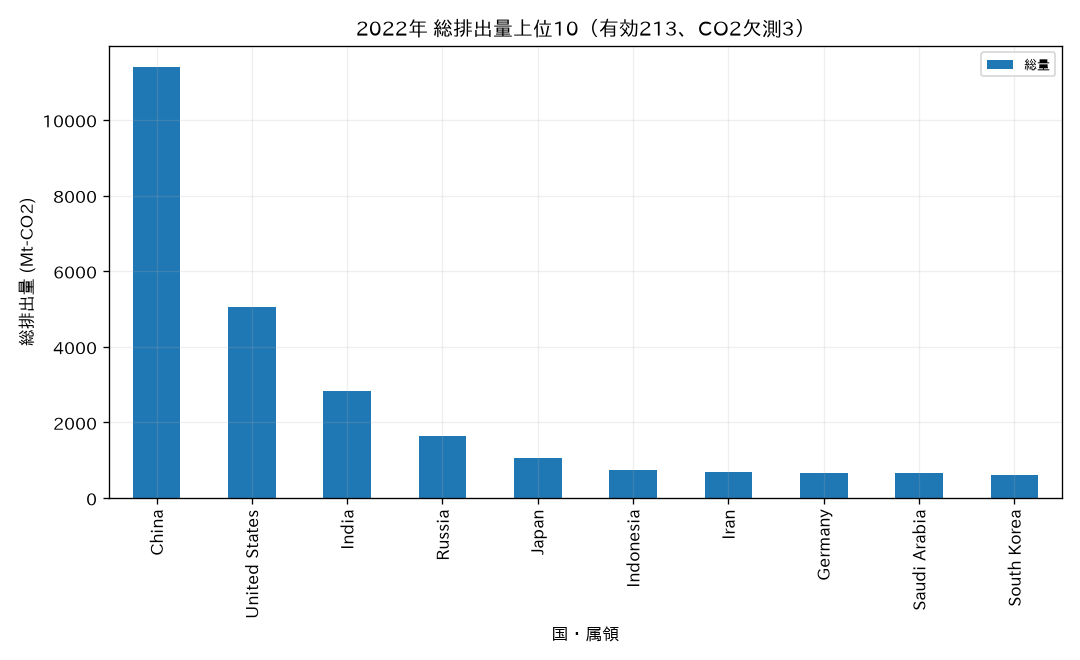

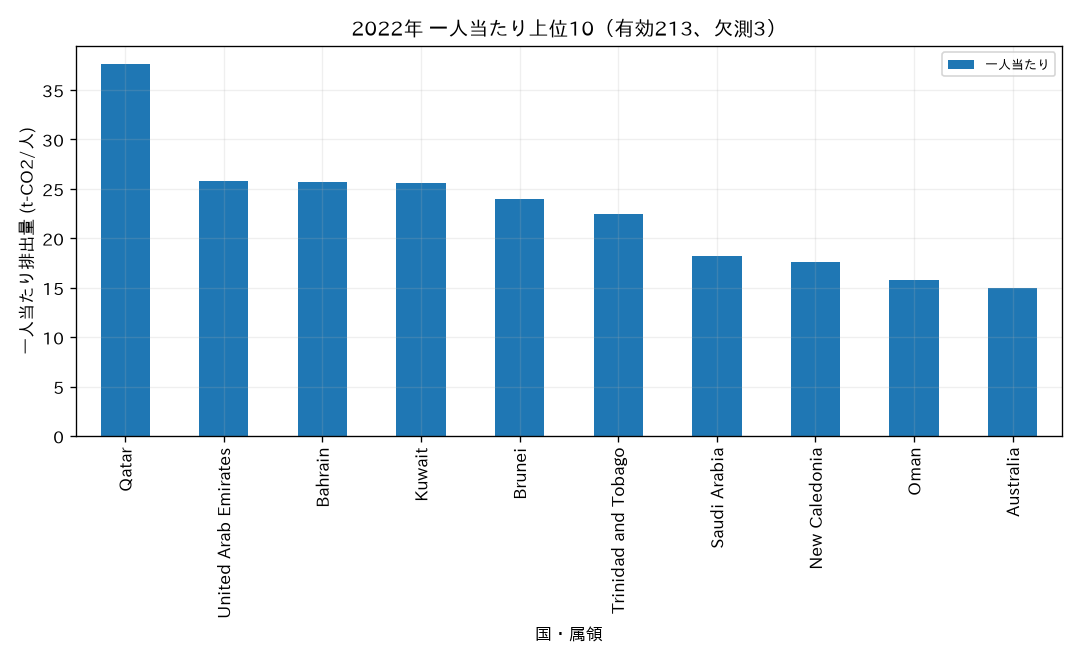

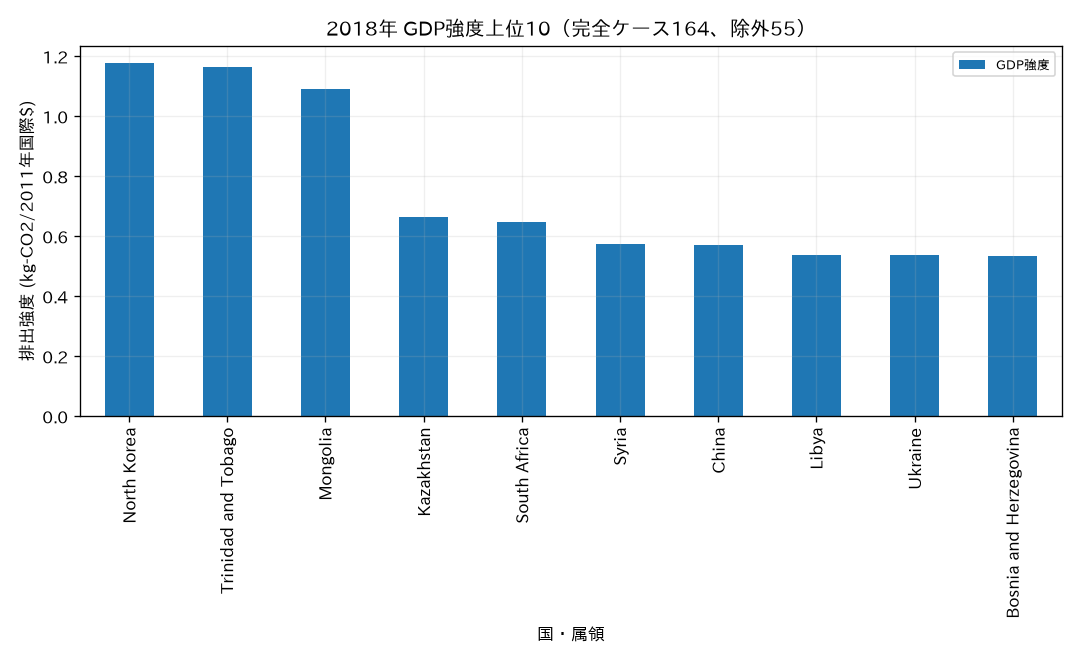

In [14]:
with execution_phase('図1–3：順位'):
    show_chart(latest_valid.nlargest(10,'co2').rename(columns={'co2':'総量'}),'01_total_2022','bar','country','総量','2022年 総排出量上位10（有効213、CO2欠測3）','国・属領','総排出量 (Mt-CO2)')
    show_chart(latest_valid.nlargest(10,'co2_per_capita').rename(columns={'co2_per_capita':'一人当たり'}),'02_pc_2022','bar','country','一人当たり','2022年 一人当たり上位10（有効213、欠測3）','国・属領','一人当たり排出量 (t-CO2/人)')
    show_chart(economy_valid.nlargest(10,'co2_per_gdp').rename(columns={'co2_per_gdp':'GDP強度'}),'03_intensity_2018','bar','country','GDP強度','2018年 GDP強度上位10（完全ケース164、除外55）','国・属領','排出強度 (kg-CO2/2011年国際$)')


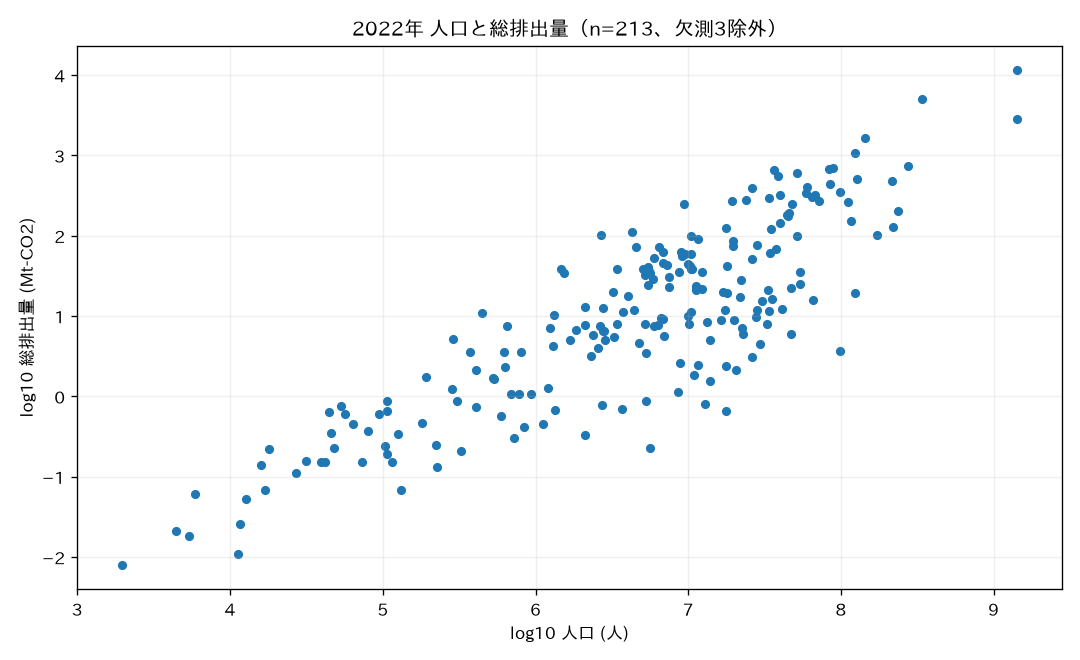

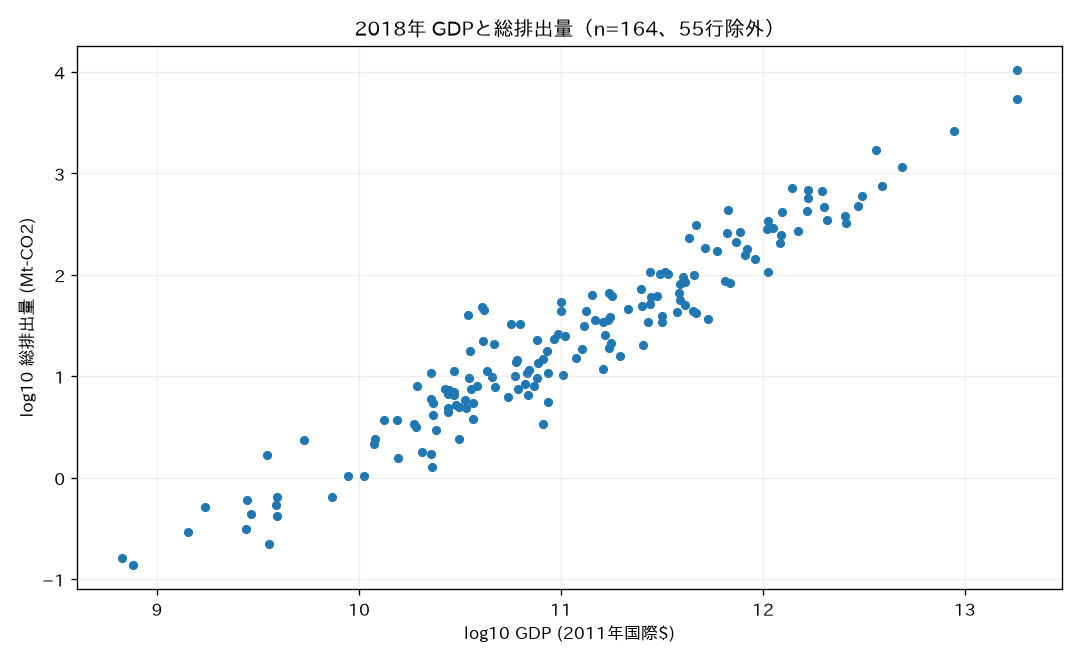

In [15]:
with execution_phase('図4–5：人口・経済規模'):
    pop_plot = pd.DataFrame({'log人口':np.log10(latest_valid.population),'log総量':np.log10(latest_valid.co2)})
    gdp_plot = pd.DataFrame({'logGDP':np.log10(economy_valid.gdp),'log総量':np.log10(economy_valid.co2)})
    show_chart(pop_plot,'04_population_2022','scatter','log人口','log総量','2022年 人口と総排出量（n=213、欠測3除外）','log10 人口 (人)','log10 総排出量 (Mt-CO2)')
    show_chart(gdp_plot,'05_gdp_2018','scatter','logGDP','log総量','2018年 GDPと総排出量（n=164、55行除外）','log10 GDP (2011年国際$)','log10 総排出量 (Mt-CO2)')


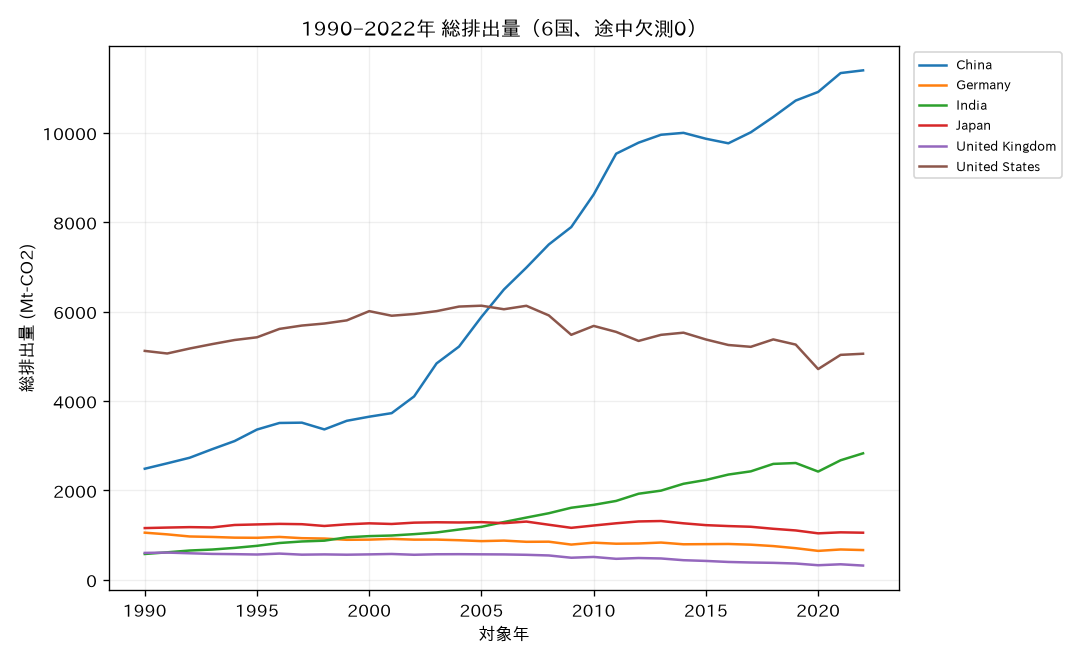

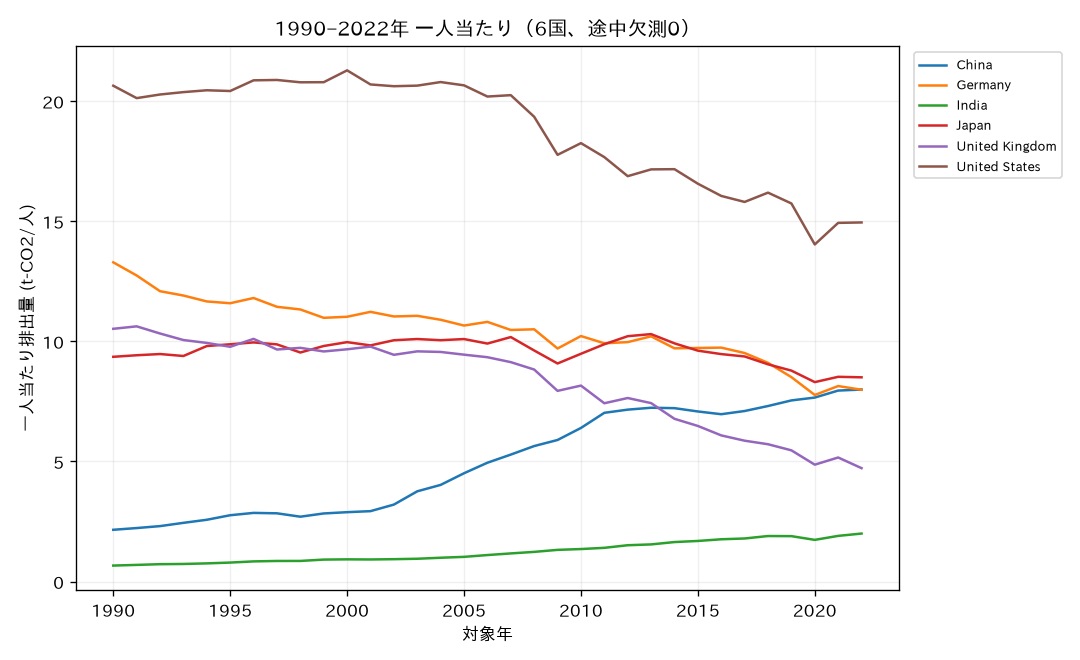

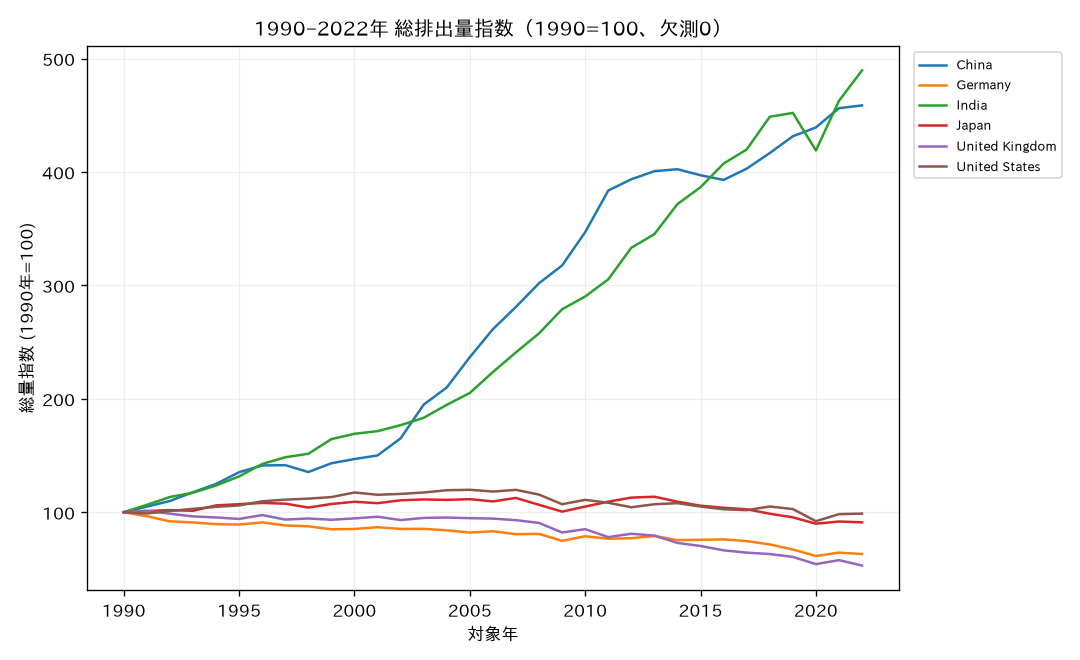

,chart_id,missing_glyphs,bytes,year_missingness
0,01_total_2022,[],43542,2022年 総排出量上位10（有効213、CO2欠測3）
1,02_pc_2022,[],49299,2022年 一人当たり上位10（有効213、欠測3）
2,03_intensity_2018,[],54097,2018年 GDP強度上位10（完全ケース164、除外55）
3,04_population_2022,[],45837,2022年 人口と総排出量（n=213、欠測3除外）
4,05_gdp_2018,[],44759,2018年 GDPと総排出量（n=164、55行除外）
5,06_total_trend,[],72161,1990–2022年 総排出量（6国、途中欠測0）
6,07_pc_trend,[],80210,1990–2022年 一人当たり（6国、途中欠測0）
7,08_index_trend,[],81524,1990–2022年 総排出量指数（1990=100、欠測0）


In [16]:
with execution_phase('図6–8：長期変化'):
    show_chart(trend_total.reset_index(),'06_total_trend','line','year',list(trend_total.columns),'1990–2022年 総排出量（6国、途中欠測0）','対象年','総排出量 (Mt-CO2)')
    show_chart(trend_pc.reset_index(),'07_pc_trend','line','year',list(trend_pc.columns),'1990–2022年 一人当たり（6国、途中欠測0）','対象年','一人当たり排出量 (t-CO2/人)')
    show_chart(trend_index.reset_index(),'08_index_trend','line','year',list(trend_index.columns),'1990–2022年 総排出量指数（1990=100、欠測0）','対象年','総量指数 (1990年=100)')
    display(pd.DataFrame(chart_logs))


## 反復依頼履歴

### 反復1：人口閾値と基準年の感度

**追加依頼文（原文）**
> 一人当たり排出の上位順位は小人口国に左右されていませんか。人口制限なし・100万人以上・500万人以上で比較し、2018年・2019年・2022年の年選択にも依存しないか調べてください。長期変化は1990年だけでなく2000年・2010年を基準にし、増減の符号が変わる国を明示してください。

**選定理由**：人口分母による順位逆転と米国のほぼ横ばいという結論が、対象国・基準年の選択に敏感な可能性がある。閾値・対象年を有限の9仕様、長期は各国3仕様に限定する。

In [17]:
with execution_phase('反復1・感度分析'):
    threshold_rows = []
    def population_analysis(year, min_population):
        frame = countries[countries.year.eq(year)].dropna(subset=['co2','population','co2_per_capita'])
        frame = frame[frame.population>=min_population]
        top = frame.nlargest(1,'co2_per_capita').iloc[0]
        threshold_rows.append({'year':year,'min_population':min_population,'n':len(frame),'excluded_vs_available':int(countries[countries.year.eq(year)].co2_per_capita.notna().sum())-len(frame),'top_pc_country':top.country,'top_pc_t_per_person':top.co2_per_capita,'top_total_country':frame.nlargest(1,'co2').iloc[0].country,'japan_pc_rank':float(frame.co2_per_capita.rank(ascending=False,method='min')[frame.country.eq('Japan')].iloc[0])})
        return top.co2_per_capita
    population_plan = sensitivity.SensitivityPlan(parameter_grid={'year':[2022,2019,2018],'min_population':[0,1_000_000,5_000_000]},max_runs=9)
    population_sensitivity = sensitivity.run_sensitivity(population_plan,population_analysis,stability_tolerance=0.2)
    display(pd.DataFrame(threshold_rows))
    print('一人当たり最大値感度:',{'stable':population_sensitivity.stable,'max_relative_deviation':population_sensitivity.max_relative_deviation,'tolerance':0.2,'baseline':'2022年・人口制限なし'})
    long_sensitivity_rows = []
    def endpoint_change(country, baseline_year):
        row0 = countries[countries.country.eq(country)&countries.year.eq(baseline_year)].iloc[0]
        row1 = latest[latest.country.eq(country)].iloc[0]
        return (row1.co2/row0.co2-1)*100
    for country in long_focus:
        report = sensitivity.run_sensitivity(sensitivity.SensitivityPlan({'baseline_year':[1990,2000,2010]},max_runs=3),lambda baseline_year: endpoint_change(country,baseline_year),stability_tolerance=0.2)
        for result in report.results:
            row0 = countries[countries.country.eq(country)&countries.year.eq(result.specification['baseline_year'])].iloc[0]
            row1 = latest[latest.country.eq(country)].iloc[0]
            long_sensitivity_rows.append({'country':country,'baseline_year':result.specification['baseline_year'],'end_year':latest_year,'total_change_pct':result.value,'pc_change_pct':(row1.co2_per_capita/row0.co2_per_capita-1)*100,'stable_20pct_relative':report.stable,'max_relative_deviation':report.max_relative_deviation})
    display(pd.DataFrame(long_sensitivity_rows).round(3))
    display({'marker':'ITERATION1_EVIDENCE','population_stable':population_sensitivity.stable,'max_relative_deviation':population_sensitivity.max_relative_deviation,'threshold_results':threshold_rows,'baseline_results':long_sensitivity_rows})
    (data_dir/'sensitivity_population_year.json').write_text(json.dumps(asdict(population_sensitivity),ensure_ascii=False,indent=2),encoding='utf-8')
    display(Markdown('**残る限界**：stableは最大一人当たり値または増減率の相対偏差に対する20%閾値であり、順位同一性・因果頑健性を保証しない。基準値がほぼ0だと相対偏差は大きくなるため、増減符号と実数値も併記した。国境変更・人口推計誤差は未検証。'))


一人当たり最大値感度: {'stable': False, 'max_relative_deviation': 0.3910534294300684, 'tolerance': 0.2, 'baseline': '2022年・人口制限なし'}


,year,min_population,n,excluded_vs_available,top_pc_country,top_pc_t_per_person,top_total_country,japan_pc_rank
0,2022,0,213,0,Qatar,37.601,China,32.0
1,2022,1000000,159,54,Qatar,37.601,China,21.0
2,2022,5000000,125,88,United Arab Emirates,25.833,China,15.0
3,2019,0,213,0,Qatar,35.985,China,33.0
4,2019,1000000,159,54,Qatar,35.985,China,21.0
5,2019,5000000,121,92,United Arab Emirates,23.835,China,14.0
6,2018,0,213,0,Qatar,34.504,China,32.0
7,2018,1000000,159,54,Qatar,34.504,China,21.0
8,2018,5000000,121,92,United Arab Emirates,22.897,China,14.0


,country,baseline_year,end_year,total_change_pct,pc_change_pct,stable_20pct_relative,max_relative_deviation
0,China,1990,2022,358.650,271.077,False,0.910
1,China,2000,2022,212.309,176.862,False,0.910
2,China,2010,2022,32.204,25.008,False,0.910
3,United States,1990,2022,-1.243,-27.575,False,11.755
4,United States,2000,2022,-15.854,-29.753,False,11.755
5,United States,2010,2022,-10.958,-18.091,False,11.755
6,India,1990,2022,389.561,200.753,False,0.824
7,India,2000,2022,189.470,116.360,False,0.824
8,India,2010,2022,68.699,47.707,False,0.824
9,Japan,1990,2022,-8.935,-9.128,False,0.859


{'marker': 'ITERATION1_EVIDENCE',
 'population_stable': False,
 'max_relative_deviation': 0.3910534294300684,
 'threshold_results': [{'year': 2022,
   'min_population': 0,
   'n': 213,
   'excluded_vs_available': 0,
   'top_pc_country': 'Qatar',
   'top_pc_t_per_person': np.float64(37.601),
   'top_total_country': 'China',
   'japan_pc_rank': 32.0},
  {'year': 2022,
   'min_population': 1000000,
   'n': 159,
   'excluded_vs_available': 54,
   'top_pc_country': 'Qatar',
   'top_pc_t_per_person': np.float64(37.601),
   'top_total_country': 'China',
   'japan_pc_rank': 21.0},
  {'year': 2022,
   'min_population': 5000000,
   'n': 125,
   'excluded_vs_available': 88,
   'top_pc_country': 'United Arab Emirates',
   'top_pc_t_per_person': np.float64(25.833),
   'top_total_country': 'China',
   'japan_pc_rank': 15.0},
  {'year': 2019,
   'min_population': 0,
   'n': 213,
   'excluded_vs_available': 0,
   'top_pc_country': 'Qatar',
   'top_pc_t_per_person': np.float64(35.985),
   'top_total_co

**残る限界**：stableは最大一人当たり値または増減率の相対偏差に対する20%閾値であり、順位同一性・因果頑健性を保証しない。基準値がほぼ0だと相対偏差は大きくなるため、増減符号と実数値も併記した。国境変更・人口推計誤差は未検証。

**反復1の結果・証拠・残る限界**

100万人以上でも一人当たり1位はカタールだが、500万人以上ではUAE（2022年25.833 t/人）になる。総量1位中国は9仕様で不変。日本の一人当たり順位は2022年32位から、100万人以上で21位、500万人以上で15位となるため、母集団なしの順位を固定的な評価に使わない。最大一人当たり値の感度は**stable=False、最大相対偏差0.3911（39.1%）**。

主要6国の長期増減方向は1990・2000・2010基準で変わらない。ただし米国総量は1990基準−1.243%、2000基準−15.854%、2010基準−10.958%であり、「横ばい」は1990基準に限定される。変化率の20%相対許容で英国のみstable=True、他国はFalse。国境変更・測定誤差は未解決。

**次に読むべき点**：GDP完全ケース164国属領が排出量の大部分をカバーするか、人口・所得・排出強度の積に分けると減少解釈が変わるかを確認する。

```evidence
{"execution_count": 17, "cited_value": "ITERATION1_EVIDENCE", "claim_type": "descriptive"}
```

### 反復2：GDP欠測の構成差と規模分解

**追加依頼文（原文）**
> GDPあり国だけに絞ることで総排出量や一人当たり排出の比較が歪んでいないか、2018年のGDPあり・なしの国数、排出量カバー率、人口加重・非加重平均を比べてください。主要6国の1990〜2018年の排出変化を人口、一人当たりGDP、GDP当たり排出の積に分解し、所得と排出の相関が年・人口閾値・大排出国除外で安定しているか確認してください。

**選定理由**：GDP欠測は54国属領あり、経済比較の選択バイアスを定量化する必要がある。3年×3人口閾値×大排出国除外2条件の18仕様で相関の頑健性を確認する。分解は会計恒等式で、因果寄与ではない。

In [18]:
with execution_phase('反復2・GDP欠測と会計分解'):
    e2018 = economy.dropna(subset=['co2','co2_per_capita','population']).query('population > 0').copy()
    e2018['gdp_group'] = np.where(e2018.gdp.notna(),'GDP観測あり','GDP欠測')
    group_rows = []
    for group, frame in e2018.groupby('gdp_group'):
        group_rows.append({'group':group,'year':economy_year,'n':len(frame),'co2_Mt':frame.co2.sum(),'population':frame.population.sum(),'emissions_share_country_sum_pct':frame.co2.sum()/e2018.co2.sum()*100,'pc_unweighted_t':frame.co2_per_capita.mean(),'pc_population_weighted_t':frame.co2.sum()*1e6/frame.population.sum()})
    print('分母は2018年の国・属領CO₂有効213行の和。世界集計ではない（国際輸送等は含まない）。')
    display(pd.DataFrame(group_rows).round(4))
    excluded_economy = economy[~economy.country.isin(economy_valid.country)]
    print('完全ケース除外国・属領:',excluded_economy.country.tolist())
    gdp_missing_important = e2018[e2018.gdp.isna()].nlargest(8,'co2')[['country','co2','co2_per_capita','population']]
    display(gdp_missing_important)
    decomposition_rows = []
    for country in long_focus:
        rows = countries[countries.country.eq(country)&countries.year.isin([1990,2018])].set_index('year')
        a,b = rows.loc[1990],rows.loc[2018]
        assert all(pd.notna(r[c]) and r[c]>0 for r in [a,b] for c in ['population','gdp','co2'])
        ratios = {'population':b.population/a.population,'gdp_pc':(b.gdp/b.population)/(a.gdp/a.population),'co2_gdp':(b.co2/b.gdp)/(a.co2/a.gdp)}
        total_ratio = b.co2/a.co2
        product = np.prod(list(ratios.values()))
        assert np.isclose(total_ratio,product,rtol=1e-12)
        decomposition_rows.append({'country':country,'start':1990,'end':2018,'emissions_change_pct':(total_ratio-1)*100,'population_factor':ratios['population'],'GDP_pc_factor':ratios['gdp_pc'],'CO2_GDP_factor':ratios['co2_gdp'],'dlog_CO2':np.log(total_ratio),'dlog_population':np.log(ratios['population']),'dlog_GDP_pc':np.log(ratios['gdp_pc']),'dlog_CO2_GDP':np.log(ratios['co2_gdp']),'identity_error':product-total_ratio})
    display(pd.DataFrame(decomposition_rows).round(4))
    economic_sensitivity_rows = []
    def economy_correlation(year,min_population,drop_top_n):
        frame = countries[countries.year.eq(year)].dropna(subset=['gdp','co2_per_capita','population','co2']).query('gdp > 0 and population > 0 and co2_per_capita > 0')
        frame = frame[frame.population>=min_population]
        frame = frame.drop(frame.nlargest(drop_top_n,'co2').index)
        frame = frame.assign(gdp_pc=frame.gdp/frame.population)
        r = np.log10(frame.gdp_pc).corr(np.log10(frame.co2_per_capita))
        economic_sensitivity_rows.append({'year':year,'min_population':min_population,'drop_top_n':drop_top_n,'n':len(frame),'r_log_gdp_pc_co2_pc':r})
        return r
    economic_plan = sensitivity.SensitivityPlan({'year':[2018,2015,2010],'min_population':[0,1_000_000,5_000_000],'drop_top_n':[0,3]},max_runs=18)
    economic_sensitivity = sensitivity.run_sensitivity(economic_plan,economy_correlation,stability_tolerance=0.2)
    display(pd.DataFrame(economic_sensitivity_rows))
    display({'marker':'ITERATION2_EVIDENCE','gdp_groups':group_rows,'decomposition':decomposition_rows,'stable':economic_sensitivity.stable,'max_relative_deviation':economic_sensitivity.max_relative_deviation,'r_min':min(x['r_log_gdp_pc_co2_pc'] for x in economic_sensitivity_rows),'r_max':max(x['r_log_gdp_pc_co2_pc'] for x in economic_sensitivity_rows)})
    (data_dir/'sensitivity_economic.json').write_text(json.dumps(asdict(economic_sensitivity),ensure_ascii=False,indent=2),encoding='utf-8')
    display(Markdown('**残る限界**：GDP欠測は無作為ではない。排出カバー率が高くても、欠測国のGDP強度を推定したことにはならない。分解の経済項・強度項は定義上の恒等式であり、政策効果や技術効率の因果的分離ではない。'))


分母は2018年の国・属領CO₂有効213行の和。世界集計ではない（国際輸送等は含まない）。
完全ケース除外国・属領: ['Andorra', 'Anguilla', 'Antarctica', 'Antigua and Barbuda', 'Aruba', 'Bahamas', 'Belize', 'Bermuda', 'Bhutan', 'Bonaire Sint Eustatius and Saba', 'British Virgin Islands', 'Brunei', 'Christmas Island', 'Cook Islands', 'Curacao', 'East Timor', 'Eritrea', 'Faroe Islands', 'Fiji', 'French Polynesia', 'Greenland', 'Grenada', 'Guyana', 'Kiribati', 'Liechtenstein', 'Macao', 'Maldives', 'Marshall Islands', 'Micronesia (country)', 'Monaco', 'Montserrat', 'Nauru', 'New Caledonia', 'Niue', 'Palau', 'Papua New Guinea', 'Puerto Rico', 'Saint Helena', 'Saint Kitts and Nevis', 'Saint Pierre and Miquelon', 'Saint Vincent and the Grenadines', 'Samoa', 'San Marino', 'Sint Maarten (Dutch part)', 'Solomon Islands', 'Somalia', 'South Sudan', 'Sudan', 'Suriname', 'Tonga', 'Turks and Caicos Islands', 'Tuvalu', 'Vanuatu', 'Vatican', 'Wallis and Futuna']


,group,year,n,co2_Mt,population,emissions_share_country_sum_pct,pc_unweighted_t,pc_population_weighted_t
0,GDP欠測,2018,49,74.938,9.057752e+07,0.2111,5.3924,0.8273
1,GDP観測あり,2018,164,35422.546,7.584542e+09,99.7889,4.7361,4.6704


,country,co2,co2_per_capita,population
41869,Sudan,21.755,0.518,41999064.0
6977,Brunei,9.344,21.517,434283.0
34812,Papua New Guinea,7.607,0.815,9329233.0
30389,New Caledonia,5.913,20.756,284887.0
10945,Curacao,4.313,23.345,184734.0
18805,Guyana,2.503,3.186,785518.0
3987,Bahamas,2.422,6.026,401911.0
42042,Suriname,2.089,3.519,593729.0


,country,start,end,emissions_change_pct,population_factor,GDP_pc_factor,CO2_GDP_factor,dlog_CO2,dlog_population,dlog_GDP_pc,dlog_CO2_GDP,identity_error
0,China,1990,2018,316.6817,1.2283,4.3656,0.7771,1.4272,0.2056,1.4738,-0.2522,-0.0
1,United States,1990,2018,5.0155,1.3388,1.4648,0.5355,0.0489,0.2918,0.3817,-0.6246,0.0
2,India,1990,2018,348.6291,1.5727,3.2085,0.8891,1.5010,0.4528,1.1658,-0.1176,0.0
3,Japan,1990,2018,-1.3418,1.0208,1.2887,0.7500,-0.0135,0.0206,0.2536,-0.2877,-0.0
4,Germany,1990,2018,-28.4364,1.0444,1.8460,0.3712,-0.3346,0.0435,0.6130,-0.9911,0.0
5,United Kingdom,1990,2018,-36.9162,1.1612,1.4529,0.3739,-0.4607,0.1495,0.3735,-0.9837,-0.0


,year,min_population,drop_top_n,n,r_log_gdp_pc_co2_pc
0,2018,0,0,164,0.924098
1,2018,0,3,161,0.924643
2,2018,1000000,0,153,0.923660
3,2018,1000000,3,150,0.924191
4,2018,5000000,0,117,0.926670
5,2018,5000000,3,114,0.927352
6,2015,0,0,164,0.933043
7,2015,0,3,161,0.933768
8,2015,1000000,0,153,0.932012
9,2015,1000000,3,150,0.932733


{'marker': 'ITERATION2_EVIDENCE',
 'gdp_groups': [{'group': 'GDP欠測',
   'year': 2018,
   'n': 49,
   'co2_Mt': np.float64(74.93799999999999),
   'population': np.float64(90577517.0),
   'emissions_share_country_sum_pct': np.float64(0.21110791964861508),
   'pc_unweighted_t': np.float64(5.392408163265307),
   'pc_population_weighted_t': np.float64(0.8273355517131253)},
  {'group': 'GDP観測あり',
   'year': 2018,
   'n': 164,
   'co2_Mt': np.float64(35422.546),
   'population': np.float64(7584541909.0),
   'emissions_share_country_sum_pct': np.float64(99.7888920803514),
   'pc_unweighted_t': np.float64(4.736134146341462),
   'pc_population_weighted_t': np.float64(4.67036063944307)}],
 'decomposition': [{'country': 'China',
   'start': 1990,
   'end': 2018,
   'emissions_change_pct': np.float64(316.68165748102),
   'population_factor': np.float64(1.2282779674601374),
   'GDP_pc_factor': np.float64(4.365605263189109),
   'CO2_GDP_factor': np.float64(0.7770755724348707),
   'dlog_CO2': np.float

**残る限界**：GDP欠測は無作為ではない。排出カバー率が高くても、欠測国のGDP強度を推定したことにはならない。分解の経済項・強度項は定義上の恒等式であり、政策効果や技術効率の因果的分離ではない。

**反復2の結果・証拠・残る限界**

2018年のCO₂・人口・一人当たりが揃う213国属領のうち、GDPあり164行で国別CO₂和の**99.7889%**をカバーする。GDPなし49行は0.2111%で、排出総量の主要国比較は大きく欠けていない。ただし非加重一人当たり平均はGDPなし群5.3924 t/人、人口加重平均は0.8273 t/人と逆の印象になり、小国を同じ重みで数えるかで見え方が変わる。GDPあり群はそれぞれ4.7361、4.6704 t/人。国別和は世界集計でなく、欠測群にGDP強度を補ったわけではない。

1990→2018年の恒等分解では、中国は人口×1.2283、一人当たりGDP×4.3656、GDP強度×0.7771、米国は×1.3388、×1.4648、×0.5355。強度低下があっても規模・所得項がそれを相殺し、総量は中国+316.7%、米国+5.0%となる。GDP比が低下することと総量削減は同じではない。

一人当たりGDPと一人当たり排出のlog相関は18仕様で**0.9237〜0.9382、stable=True、最大相対偏差0.01527**。これは指定仕様内の関連の安定性で、因果・産業効率の証明ではない。米国は2018終点では増加、初回2022終点では小幅減だったため、終点依存と生産・消費ベースの違いを最後に確認する。

```evidence
{"execution_count": 18, "cited_value": "ITERATION2_EVIDENCE", "claim_type": "descriptive"}
```

### 反復3：排出境界と終点依存

**追加依頼文（原文）**
> 生産ベースの排出減少をそのまま消費の脱炭素化と読めない可能性を確認してください。同じ年・同じ国で消費ベースと生産ベースを比べ、土地利用変化を含む場合の総量順位の違いも示してください。また1990年からの変化を2018年・2019年・2021年・2022年終点で比較し、米国や日本の増減方向が終点に依存するか確認してください。

**選定理由**：反復2で米国の増減方向が終点に依存することが分かった。また総量を消費責任と誤読しないため、消費ベース・土地利用境界を同じCSV内で比較する。これは独立データ検証ではない。

消費・生産比較: {'year': 2021, 'country_territory_rows': 219, 'paired_valid_n': 120, 'excluded': 99, 'latest_2022_consumption_missing': 216}
土地利用比較: {'year': 2022, 'paired_valid_n': 194, 'excluded': 22, 'negative_net_with_luc_n': 2}


,country,year,co2,consumption_co2,co2_per_capita,consumption_co2_per_capita,consumption_production_ratio,consumption_minus_production_Mt
9121,China,2021,11336.233,10320.089,7.950,7.238,0.9104,-1016.144
17224,Germany,2021,678.799,830.510,8.138,9.957,1.2235,151.711
20136,India,2021,2674.222,2447.725,1.900,1.739,0.9153,-226.497
21838,Japan,2021,1062.129,1224.912,8.523,9.830,1.1533,162.783
45554,United Kingdom,2021,347.465,513.400,5.164,7.631,1.4776,165.935
45777,United States,2021,5032.213,5572.173,14.932,16.535,1.1073,539.960


,country,start,end,production_change_pct,consumption_change_pct
0,China,1990,2021,356.213,344.765
1,United States,1990,2021,-1.733,10.383
2,India,1990,2021,362.671,325.370
3,Japan,1990,2021,-8.215,-7.024
4,Germany,1990,2021,-35.643,-30.497
5,United Kingdom,1990,2021,-42.276,-23.328


,country,year,co2,co2_including_luc,rank_without_luc,rank_with_luc
9122,China,2022,11396.777,12378.281,1.0,1.0
45778,United States,2022,5057.304,5199.053,2.0,2.0
20137,India,2022,2829.644,2864.052,3.0,3.0
36425,Russia,2022,1652.177,1965.207,4.0,4.0
20310,Indonesia,2022,728.883,1647.497,6.0,5.0
6536,Brazil,2022,483.477,1596.469,13.0,6.0
21839,Japan,2022,1053.798,1058.027,5.0,7.0
27792,Mexico,2022,511.972,862.686,12.0,8.0
20801,Iran,2022,690.635,677.454,7.0,9.0
38345,Saudi Arabia,2022,662.549,666.512,9.0,10.0


,country,start,end,total_change_pct,pc_change_pct
0,China,1990,2018,316.682,239.229
1,China,1990,2019,331.455,250.046
2,China,1990,2021,356.213,269.081
3,China,1990,2022,358.650,271.077
4,United States,1990,2018,5.015,-21.563
5,United States,1990,2019,2.757,-23.748
6,United States,1990,2021,-1.733,-27.662
7,United States,1990,2022,-1.243,-27.575
8,India,1990,2018,348.629,185.241
9,India,1990,2019,352.060,184.488


{'marker': 'ITERATION3_EVIDENCE',
 'boundary_year': 2021,
 'paired_n': 120,
 'boundary_focus': [{'country': 'China',
   'co2': 11336.233,
   'consumption_co2': 10320.089,
   'consumption_production_ratio': 0.9103631691409306},
  {'country': 'Germany',
   'co2': 678.799,
   'consumption_co2': 830.51,
   'consumption_production_ratio': 1.223499150705879},
  {'country': 'India',
   'co2': 2674.222,
   'consumption_co2': 2447.725,
   'consumption_production_ratio': 0.9153035911005144},
  {'country': 'Japan',
   'co2': 1062.129,
   'consumption_co2': 1224.912,
   'consumption_production_ratio': 1.1532610445623839},
  {'country': 'United Kingdom',
   'co2': 347.465,
   'consumption_co2': 513.4,
   'consumption_production_ratio': 1.4775588908235362},
  {'country': 'United States',
   'co2': 5032.213,
   'consumption_co2': 5572.173,
   'consumption_production_ratio': 1.1073007044813088}],
 'long_boundary_changes': [{'country': 'China',
   'start': 1990,
   'end': 2021,
   'production_change_pc

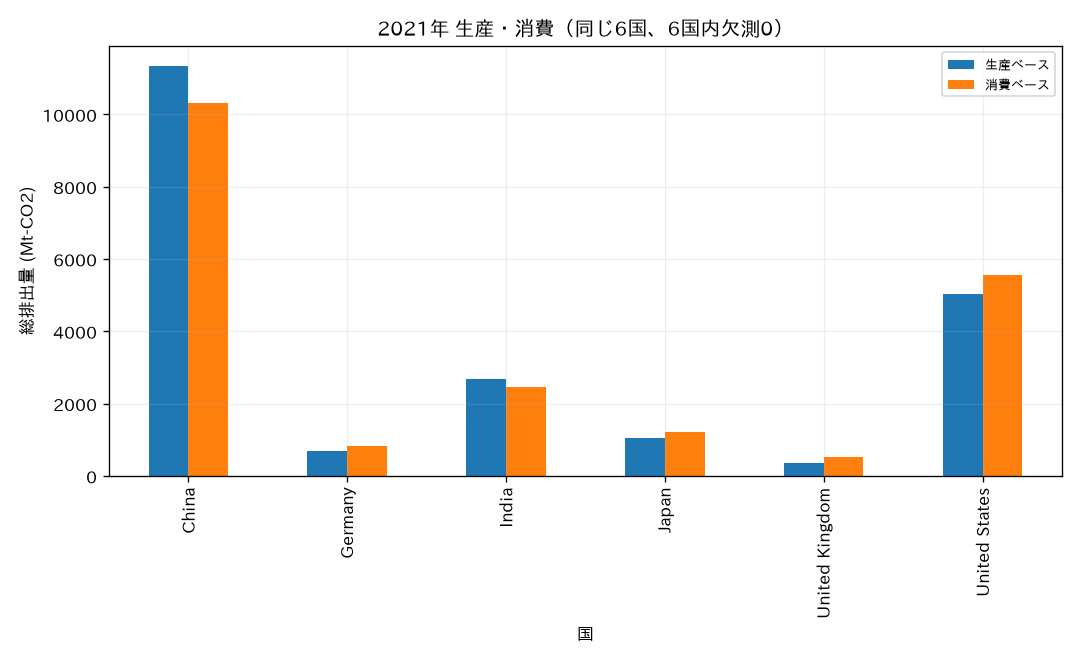

**残る限界・停止判断**：消費ベースは貿易調整のモデル推計であり個人の責任配分ではない。土地利用は正負のネット値を取り得る。国境変更、国際輸送、GDP欠測国の強度、測定不確実性はこのCSVだけでは解決できない。主要な比較軸は確認したため、これ以上は別の検証済み資料を要し、推測の追加データを使わず3回で反復を終了する。

In [19]:
with execution_phase('反復3・排出境界と終点'):
    boundary_counts = countries.dropna(subset=['co2','consumption_co2','co2_per_capita','consumption_co2_per_capita']).groupby('year').size()
    boundary_year = int(boundary_counts[boundary_counts>=100].index.max())
    boundary = countries[countries.year.eq(boundary_year)].dropna(subset=['co2','consumption_co2','co2_per_capita','consumption_co2_per_capita']).copy()
    boundary['consumption_production_ratio'] = boundary.consumption_co2/boundary.co2
    boundary['consumption_minus_production_Mt'] = boundary.consumption_co2-boundary.co2
    boundary_focus = boundary[boundary.country.isin(long_focus)].copy()
    print('消費・生産比較:',{'year':boundary_year,'country_territory_rows':int((countries.year==boundary_year).sum()),'paired_valid_n':len(boundary),'excluded':int((countries.year==boundary_year).sum())-len(boundary),'latest_2022_consumption_missing':int(latest.consumption_co2.isna().sum())})
    display(boundary_focus[['country','year','co2','consumption_co2','co2_per_capita','consumption_co2_per_capita','consumption_production_ratio','consumption_minus_production_Mt']].round(4))
    consumption_changes = []
    for country in long_focus:
        a = countries[countries.country.eq(country)&countries.year.eq(1990)].iloc[0]
        b = boundary_focus[boundary_focus.country.eq(country)].iloc[0]
        consumption_changes.append({'country':country,'start':1990,'end':boundary_year,'production_change_pct':(b.co2/a.co2-1)*100,'consumption_change_pct':(b.consumption_co2/a.consumption_co2-1)*100 if pd.notna(a.consumption_co2) and a.consumption_co2>0 else None})
    display(pd.DataFrame(consumption_changes).round(3))
    luc = latest.dropna(subset=['co2','co2_including_luc']).copy()
    luc['rank_without_luc'] = luc.co2.rank(ascending=False,method='min')
    luc['rank_with_luc'] = luc.co2_including_luc.rank(ascending=False,method='min')
    print('土地利用比較:',{'year':latest_year,'paired_valid_n':len(luc),'excluded':len(latest)-len(luc),'negative_net_with_luc_n':int((luc.co2_including_luc<0).sum())})
    luc_top = luc[luc.rank_without_luc.le(10)|luc.rank_with_luc.le(10)][['country','year','co2','co2_including_luc','rank_without_luc','rank_with_luc']].sort_values('rank_with_luc')
    display(luc_top.round(3))
    endpoint_rows = []
    for country in long_focus:
        for end_year in [2018,2019,2021,2022]:
            a = countries[countries.country.eq(country)&countries.year.eq(1990)].iloc[0]
            b = countries[countries.country.eq(country)&countries.year.eq(end_year)].iloc[0]
            endpoint_rows.append({'country':country,'start':1990,'end':end_year,'total_change_pct':(b.co2/a.co2-1)*100,'pc_change_pct':(b.co2_per_capita/a.co2_per_capita-1)*100})
    display(pd.DataFrame(endpoint_rows).round(3))
    # 境界別のJapan/China一人当たり比：絶対値の異なる仕様でも比較可能な同じ問い。
    boundary_sensitivity_rows = []
    def boundary_ratio(measure):
        j = boundary_focus[boundary_focus.country.eq('Japan')].iloc[0]
        c = boundary_focus[boundary_focus.country.eq('China')].iloc[0]
        ratio = j[measure]/c[measure]
        boundary_sensitivity_rows.append({'year':boundary_year,'measure':measure,'Japan_China_pc_ratio':ratio})
        return ratio
    boundary_sensitivity = sensitivity.run_sensitivity(sensitivity.SensitivityPlan({'measure':['co2_per_capita','consumption_co2_per_capita']},max_runs=2),boundary_ratio,stability_tolerance=0.2)
    display({'marker':'ITERATION3_EVIDENCE','boundary_year':boundary_year,'paired_n':len(boundary),'boundary_focus':boundary_focus[['country','co2','consumption_co2','consumption_production_ratio']].to_dict('records'),'long_boundary_changes':consumption_changes,'luc_top':luc_top.to_dict('records'),'endpoints':endpoint_rows,'boundary_ratio':boundary_sensitivity_rows,'stable':boundary_sensitivity.stable,'max_relative_deviation':boundary_sensitivity.max_relative_deviation})
    show_chart(boundary_focus.set_index('country')[['co2','consumption_co2']].rename(columns={'co2':'生産ベース','consumption_co2':'消費ベース'}).reset_index(),'09_boundary_comparison','bar','country',['生産ベース','消費ベース'],f'{boundary_year}年 生産・消費（同じ6国、6国内欠測0）','国','総排出量 (Mt-CO2)')
    (data_dir/'sensitivity_boundary.json').write_text(json.dumps(asdict(boundary_sensitivity),ensure_ascii=False,indent=2),encoding='utf-8')
    display(Markdown('**残る限界・停止判断**：消費ベースは貿易調整のモデル推計であり個人の責任配分ではない。土地利用は正負のネット値を取り得る。国境変更、国際輸送、GDP欠測国の強度、測定不確実性はこのCSVだけでは解決できない。主要な比較軸は確認したため、これ以上は別の検証済み資料を要し、推測の追加データを使わず3回で反復を終了する。'))


**反復3の結果・証拠・残る限界**

消費ベースは2021年までで、2021年の対応する有効比較は120国属領（99行除外）。主要6国には欠測がない。同年の消費/生産比は日本**1.1533**、英国1.4776、米国1.1073、中国0.9104。1990→2021年の米国は生産ベース−1.733%でも消費ベース**+10.383%**で、減少の結論が排出境界で変わる。英国は−42.276%対−23.328%、日本は−8.215%対−7.024%。

日本/中国の一人当たり比は2021年生産ベース1.0721、消費ベース1.3581。**stable=False、最大相対偏差0.2668**で、相対的な大きさは境界に敏感。2022年の土地利用込み194国属領内ではブラジル13位→6位、日本5位→7位となる。最新年の全213国比較とは母集団が違う。土地利用込みはネット吸収で負になる国が2つあり、単純な負値除去はしない。

米国の1990比総量は2018年+5.015%、2019年+2.757%、2021年−1.733%、2022年−1.243%で終点により符号が変わる。一人当たりは4終点すべて減少。日本は両指標とも4終点で減少。したがって**米国総量の「削減」は期間・境界を伴わない一般化をしない**。推計誤差、国境変更、欠測国のGDP強度、独立参照による検証は残る。主要な解釈差を確認し、検証済み追加資料がないため3反復で停止する。

```evidence
{"execution_count": 19, "cited_value": "ITERATION3_EVIDENCE", "claim_type": "descriptive"}
```

## 統合した結論

総量は大人口・大経済国の影響を捉え、一人当たりは人口分母を取り除いた排出水準、GDP強度は経済産出に対する排出を捉える。同じ国でも指標・年・人口閾値・加重方法・排出境界で評価が変わる。中国の総量1位と湾岸国の高い一人当たりは確認できるが、誰の責任か、どの政策が効いたかはこの比較からは判断しない。

最新排出は2022年、GDP比較は2018年、消費ベースは2021年。これらを同年の結果と誤認しない。長期変化は基準年・終点を併記し、特に米国総量の方向は終点と生産/消費境界に依存する。表・図の詳しい根拠は初回と各反復のevidenceに記録した。

未確定事項はライセンス本文未確認、ISO抽出の主権国家/属領区分と歴史的境界、独立データの未検証である。GDP欠測国を含めた強度順位や現在2026年の排出状況を示すデータではない。

## Jupytermind改善候補

### 1. 日本語フォントのCO₂欠字（不具合疑い）

**分類**：可視化・文字対応。**再現条件**：`visualization.render_chart`に日本語とU+2082（下付き2）を含むタイトル/軸名を渡す。**期待**：日本語と一般的なCO₂表記が欠字なく描画されるか、欠字が明示される。**実際**：IPAexGothicにGlyph 8322なしというMatplotlib警告が発生。初回の図1描画は本Notebookの欠字ガードで停止。**影響**：化学式の下付き2が欠落して可読性を損なう。**回避策**：図の表記をCO2へ替え、すべての最終図で警告0を確認。**関係セル・ログ**：セル13 `show_chart`、セル15初回失敗、`data/initial_visual_failure.json`、下の再現検査セル。

### 2. visual_auditでチャートmetadata全欠落を見逃す（機能不足／監査ギャップ）

**分類**：Notebook可視監査。**再現条件**：`render_chart`→`build_image_output`を、`metadata.chart`なしの実行済みセルへ保存し`audit_visual_outputs`する。**期待**：タイトル・軸名・legend・欠字検査情報が未記録なら不足として報告。**実際**：metadataが空だとラベル検査自体をスキップし、欠字情報も確認しない。**影響**：監査OKが図の文字・ラベルを検査した保証にならない。**回避策**：本Notebookではchart metadataを明示し、描画警告捕捉と画像の目視確認を併用。**関係セル・ログ**：セル15〜17/25、下の再現検査セルのmetadataなし監査結果。

**切り分け**：いずれも同じJupyterカーネル内でJupytermind関数の最小入力だけから再現する。Kaggle API取得は成功。保存先ディレクトリ不存在やfilesystem MCPの許可範囲は実行環境側の問題で、上記候補には含めない。Copilot CLI／ベンチマークランナーの問題として登録していない。ソフトウェア変更・GitHub Issue作成は今回の対象外。

### 3. 実行セルからの自己Notebook書換えで出力・実行回数が残らない（統合上の不具合疑い）

**分類**：Jupytermind `project_manager.enqueue_write` とJupyter MCPの保存競合。**再現条件**：最終セル実行中に同じNotebookへ根拠/metadata更新をenqueue_writeする。**期待**：変更と実行出力・execution_countが両方残る。**実際**：カーネルでは最終状態completedと変数が存在したが、セル32のexecution_count=None・outputs=0。**影響**：監査の自己監査例外により未保存の実行結果を見逃し得る。**回避策**：セル中の自己Notebook書込みをやめ、MCP execute_cell完了後にenqueue_writeでmetadataを保存する。修正後はセル32を再実行し、16/16セル実行済みを外部から確認する。**関係セル・ログ**：セル32、`data/self_write_integration_observation.json`、保存後監査。Jupytermind単体かJupyter MCP保存側かは未確定であり、純粋なJupytermind不具合とは断定しない。Copilot CLI・Kaggle API・ベンチマークランナーに起因する証拠はない。

In [20]:
with execution_phase('改善候補の再現・切り分け'):
    with warnings.catch_warnings(record=True) as probe_warnings:
        warnings.simplefilter('always')
        probe_png = visualization.render_chart(pd.DataFrame({'x':[1,2,3],'y':[1,4,9]}),kind='line',x='x',y='y',title='日本語CO₂の欠字再現',xlabel='値',ylabel='CO₂')
    glyph_probe = [str(w.message) for w in probe_warnings if 'Glyph' in str(w.message) and 'missing' in str(w.message)]
    probe_output = visualization.build_image_output(probe_png)
    probe_output['execution_count'] = 1
    probe_nb = nbformat.v4.new_notebook(cells=[nbformat.v4.new_code_cell('render_chart(...); build_image_output(...)',execution_count=1,outputs=[probe_output])])
    metadata_probe = notebook_audit.audit_visual_outputs(probe_nb,(0,))
    improvement_evidence = {'marker':'JUPYTERMIND_IMPROVEMENT_EVIDENCE','glyph_warning_count':len(glyph_probe),'glyph_warnings':glyph_probe,'chart_metadata_missing':not bool(probe_nb.cells[0].metadata.get('chart')),'metadata_absent_visual_findings':[asdict(x) for x in metadata_probe],'initial_failure':json.loads((data_dir/'initial_visual_failure.json').read_text()),'scope':'Jupytermind/描画フォント・監査の再現。Kaggleと独立'}
    display(improvement_evidence)
    (data_dir/'jupytermind_improvement_evidence.json').write_text(json.dumps(improvement_evidence,ensure_ascii=False,indent=2),encoding='utf-8')


{'marker': 'JUPYTERMIND_IMPROVEMENT_EVIDENCE',
 'glyph_warning_count': 2,
 'glyph_warnings': ['Glyph 8322 (\\N{SUBSCRIPT TWO}) missing from font(s) IPAexGothic.',
  'Glyph 8322 (\\N{SUBSCRIPT TWO}) missing from font(s) IPAexGothic.'],
 'chart_metadata_missing': True,
 'metadata_absent_visual_findings': [],
 'initial_failure': {'run_id': 'v020-exp-41',
  'cell_index': 15,
  'error': 'IPAexGothicにU+2082 SUBSCRIPT TWOなし',
  'chart_log': [{'chart_id': '01_total_2022',
    'missing_glyphs': ['Glyph 8322 (\\N{SUBSCRIPT TWO}) missing from font(s) IPAexGothic.',
     'Glyph 8322 (\\N{SUBSCRIPT TWO}) missing from font(s) IPAexGothic.'],
    'bytes': 44483,
    'year_missingness': '2022年 総排出量上位10（有効213、CO₂欠測3）'}],
  'lifecycle_before_recovery': {'run_id': 'v020-exp-41',
   'state': 'failed',
   'active_cell_executions': 0,
   'pending_notebook_writes': 0,
   'locks_held': 0,
   'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-41-co2-emissions/notebook

## 使用したJupytermindモジュール

直接import・呼び出したものだけを記録する。下表の全関数は本Notebookのコードセルに呼び出しがある。内部の間接importは使用済みに含めない。

| モジュール | 直接呼び出した関数・型・メソッド | 使用目的 |
|---|---|---|
| `ai_data_scientist.project_manager` | `resolve_project`, `ensure_notebook`, `ensure_data_dir`, `enqueue_write` | 保存先の安定解決、データディレクトリ作成、Notebook直列書込み |
| `ai_data_scientist.language_router` | `detect_language` | 日本語ルーティング |
| `ai_data_scientist.lifecycle` | `register_run`, `mark_execution_start/end`, `mark_write_start/end`, `is_cancel_requested`, `mark_failed`, `mark_completed`, `get_run_status`, `wait_for_quiescence` | フェーズ・失敗/回復・最終状態の記録 |
| `ai_data_scientist.ingestion` | `SourceSpec`, `ingest` | SHA確認済みCSVの読込み・行数制限確認 |
| `ai_data_scientist.cleaning` | `clean_dataset` | 完全一致重複除去、影響記録（0行除去） |
| `ai_data_scientist.eda` | `explore` | 型・欠測・要約の探索 |
| `ai_data_scientist.data_definition` | `FieldValue`, `build_manifest`, `DataDefinitionManifest.unresolved_fields` | 単位・定義・出典・未確定状態を記録 |
| `ai_data_scientist.analysis_assumptions` | `Assumption`, `AnalysisAssumptionManifest`, `check_manifest` | 対象年・欠測・国境・因果範囲と警告記録 |
| `ai_data_scientist.data_quality` | `detect_anomalies` | 年・正の分母・非負排出・国年一意性の検査 |
| `ai_data_scientist.sensitivity` | `SensitivityPlan`, `run_sensitivity` | 人口閾値・対象年・基準年・大排出国除外・排出境界の安定性検査 |
| `ai_data_scientist.stats_analysis` | `correlation` | 正値完全ケースのlog-Pearson相関、日本語解釈 |
| `ai_data_scientist.visualization` | `render_chart`, `build_image_output` | PNG生成・MIME出力・欠字再現 |
| `ai_data_scientist.insight_engine` | `extract_cited_value`, `record_insight` | 実行出力に存在する根拠トークンの抽出と解釈記録 |
| `ai_data_scientist.notebook_audit` | `audit_visual_outputs`, `audit_notebook` | 監査ギャップ再現、全セル・根拠・画像監査 |

`mcp_gateway`, `anomaly_detection`, `dataset_validation`は直接import/呼び出していない。未適用理由は分析前提セルに記録。外部ライブラリはpandas/numpy、Kaggle SDK、Matplotlib、nbformat、IPythonおよびPython標準ライブラリで、Jupytermindモジュールではない。

長期の複数系列図は凡例が線を隠さないようMatplotlibを直接使用し、凡例を図外へ配置する。PNGのNotebook出力には`visualization.build_image_output`を直接使用した。

## 全セル再実行・最終監査・ライフサイクル

カーネルを再起動し、全コードセルを上からJupyter MCP `execute_cell`で再実行する。取得ファイルはSHA-256一致済みキャッシュを使用するが、認証・検索・一覧取得のコードも再実行する。根拠execution_countを実際の再実行済み出力へ更新し、`audit_notebook(..., visual_audit=True)`、フェーズログ、終了状態をNotebook metadataとJSONへ保存する。最終セル実行中の自己監査に加え、保存後に同じ監査を再度実施する。

In [24]:
with execution_phase('最終監査準備'):
    saved = nbformat.read(handle.notebook_path,as_version=4)
    execution_ledger = [{'cell_index':i,'cell_id':c.id,'execution_count':c.execution_count,'phase':c.source.splitlines()[0]} for i,c in enumerate(saved.cells) if c.cell_type=='code' and '最終監査準備' not in c.source]
    assert all(x['execution_count'] is not None for x in execution_ledger)
    assert all(a['execution_count']<b['execution_count'] for a,b in zip(execution_ledger,execution_ledger[1:])), '上からの再実行順序が不一致'
    assert not any(log['missing_glyphs'] for log in chart_logs), '最終図に欠字あり'
    report = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    audit_payload = {**asdict(report),'ok':report.ok,'scope':'最終セル実行中の自己監査。実行完了後のpost_save_auditで最終セルも確認する。'}
    print('notebook_audit:',json.dumps(audit_payload,ensure_ascii=False,indent=2))
    if not report.ok:
        raise RuntimeError('最終Notebook監査が不合格')
lifecycle.mark_completed(RUN_ID)
final_status = lifecycle.wait_for_quiescence(RUN_ID,timeout_s=30)
assert final_status.state=='completed' and final_status.active_cell_executions==0 and final_status.pending_notebook_writes==0 and final_status.locks_held==0
(data_dir/'execution_ledger.json').write_text(json.dumps(execution_ledger,ensure_ascii=False,indent=2),encoding='utf-8')
(data_dir/'notebook_audit.json').write_text(json.dumps(audit_payload,ensure_ascii=False,indent=2),encoding='utf-8')
(data_dir/'lifecycle.json').write_text(json.dumps({'final_status':asdict(final_status),'phase_log':phase_log},ensure_ascii=False,indent=2),encoding='utf-8')
print('lifecycle:',json.dumps(asdict(lifecycle.get_run_status(RUN_ID)),ensure_ascii=False))
display({'marker':'FINAL_COMPLETED_EVIDENCE','audit_ok':report.ok,'final_state':final_status.state,'charts':len(chart_logs),'iteration_count':3,'reexecution_ledger':execution_ledger})


notebook_audit: {
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-41-co2-emissions/notebooks/kaggle-v020-kaggle-exp-41-co2-emissions.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 16,
  "executed_code_cell_count": 15,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    15,
    16,
    17,
    25
  ],
  "insight_cell_count": 4,
  "findings": [
    {
      "severity": "warning",
      "message": "Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.",
      "cell_index": 32
    }
  ],
  "visual_findings": [],
  "ok": true,
  "scope": "最終セル実行中の自己監査。実行完了後のpost_save_auditで最終セルも確認する。"
}
lifecycle: {"run_id": "v020-exp-41", "state": "completed", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-41-co2-emissions/notebooks/kaggle-v020

{'marker': 'FINAL_COMPLETED_EVIDENCE',
 'audit_ok': True,
 'final_state': 'completed',
 'charts': 9,
 'iteration_count': 3,
 'reexecution_ledger': [{'cell_index': 1,
   'cell_id': '0f0147f6',
   'execution_count': 1,
   'phase': 'from pathlib import Path'},
  {'cell_index': 2,
   'cell_id': '1e3bdde4',
   'execution_count': 2,
   'phase': "with execution_phase('Kaggle公開データ検索'):"},
  {'cell_index': 4,
   'cell_id': '43e85713',
   'execution_count': 3,
   'phase': "with execution_phase('Kaggleファイル一覧'):"},
  {'cell_index': 6,
   'cell_id': 'b2d88bf8',
   'execution_count': 4,
   'phase': "with execution_phase('Kaggle CSV取得'):"},
  {'cell_index': 8,
   'cell_id': '6dde1f31',
   'execution_count': 5,
   'phase': "with execution_phase('定義・品質・対象年'):"},
  {'cell_index': 10,
   'cell_id': 'bbe5b78c',
   'execution_count': 6,
   'phase': "with execution_phase('分析前提'):"},
  {'cell_index': 12,
   'cell_id': '15d932d3',
   'execution_count': 7,
   'phase': "with execution_phase('初回集計'):"},
  {'cell